In [ ]:
!pip install -U kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 8.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import pandas as pd
import numpy as np

from scipy.optimize import minimize
from scipy.linalg import lstsq
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from typing import Dict, Union, Tuple
from IPython.display import Image

In [ ]:
url = 'https://github.com/scunning1975/mixtape/raw/refs/heads/master/smoking.dta'
df  = pd.read_stata(url)
df['age15to24'] = df['age15to24']*100
print(df.state.nunique())
df.head()

39


,state,year,cigsale,lnincome,beer,age15to24,retprice
0,Alabama,1970.0,89.800003,NaN,NaN,17.886179,39.599998
1,Alabama,1971.0,95.400002,NaN,NaN,17.992785,42.700001
2,Alabama,1972.0,101.099998,9.498476,NaN,18.099390,42.299999
3,Alabama,1973.0,102.900002,9.550107,NaN,18.205994,42.099998
4,Alabama,1974.0,108.199997,9.537163,NaN,18.312601,43.099998


Variables description:
* cigsale: Per-capita cigarette consumption (in packs). These data are based on the total tax paid on sales of packs of cigarettes in a particular state divided by its total population.
* retprice: Average retail price per pack of cigarettes (in cents). Price figures include state sales taxes, if applicable.
* lnincome: Per-capita state personal income (logged). Source: Bureau of the Census, United States Statistical Abstract. Converted to 1997 dollars using the Consumer Price Index.
* age15to24 : State population and percent of state population aged 15–24. Source: U.S. Census Bureau.
* beer: Per-capita beer consumption. Source: Beer Institute's Brewer's Almanac. Measured as the per capita consumption of malt beverages (in gallons).

In [ ]:
fig = go.Figure()
font = 'Arial'
states = df['state'].unique()
for state in states:
    state_data = df[df['state'] == state]
    if state == 'California':
        fig.add_trace(go.Scatter(x=state_data['year'], y=state_data['cigsale'], mode='lines', name=state,
                                 line=dict(color='blue'), showlegend=False))
        fig.add_trace(go.Scatter(x=[2000], y=[state_data[state_data['year'] == 2000]['cigsale'].iloc[0]],
                    mode='markers', marker=dict(color='blue', size=10), showlegend=False))
    else:
        fig.add_trace(go.Scatter(x=state_data['year'], y=state_data['cigsale'], mode='lines', name=state, opacity=0.5,
                                 line=dict(color='lightgrey'), showlegend=False))

fig.add_annotation(x=2002, y=40, text="California", font=dict(family=font, color='blue'), showarrow=False, arrowhead=1, arrowsize=1, arrowwidth=1, ax=20)


fig.add_annotation(
    x=0.01, y=-0.17, xref="paper", yref="paper",
    text=(
        "Per-capita cigarette consumption (in packs). These data are based on the total tax paid on sales of packs of cigarettes in a particular state divided by its total population.<br>"
        "Source: Synthetic Control Methods for Comparative Case Studies: Estimating the Effect of California’s Tobacco Control Program (Abadie et al. 2010).<br>"
        "Dataset: github.com/scunning1975/mixtape/blob/master/smoking.dta"
        # "Download Source</a>."
    ),
    # text="GDP is Purchasing Power Parity (PPP)-adjusted and measured in 2002 US$<br>Source: Comparative Politics and the Synthetic Control Method (Abadie et al. 2015)<br>Download Source: https://github.com/OscarEngelbrektson/SyntheticControlMethods/blob/master/examples/datasets/german_reunification.csv",
    showarrow=False, font=dict(size=9, color="darkgrey", family=font), align="left"
)


fig.add_vline(x=1989, line=dict(color="lightcoral", width=2, dash="dash")
              ,annotation_text="Passage of<br>Prop 99", annotation_position="top left"
              ,annotation_font=dict(color="lightcoral", size=14, family=font))


fig.update_layout(
    title="""Downtrend in cigarette sales for California and other control states 1970-2000.<br>Unclear if Proposition 99 had any effect since the others also dropped simultaneously
    """,
    xaxis_title='Year',
    yaxis_title='per-capita cigarette sale (in pack)',
    # yaxis_tickprefix='$',
    template='plotly_white',
    height=600,width=800,
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False),
    margin=dict(t=70, r=20),#, b=10),
)

fig.update_xaxes(
    tickfont=dict(color='grey', size=10),
    tickcolor='grey',
    title_font=dict(color='grey', size=10, family=font),
)

fig.update_yaxes(

    title_font=dict(color='grey', size=10, family=font),
    showgrid=False,
    linecolor='lightgrey',
    tickfont=dict(color='grey', size=10),
    tickcolor='grey',
)

# Show plot
fig.show()
fig.write_image("prop99_overall_trend.png", scale=6)

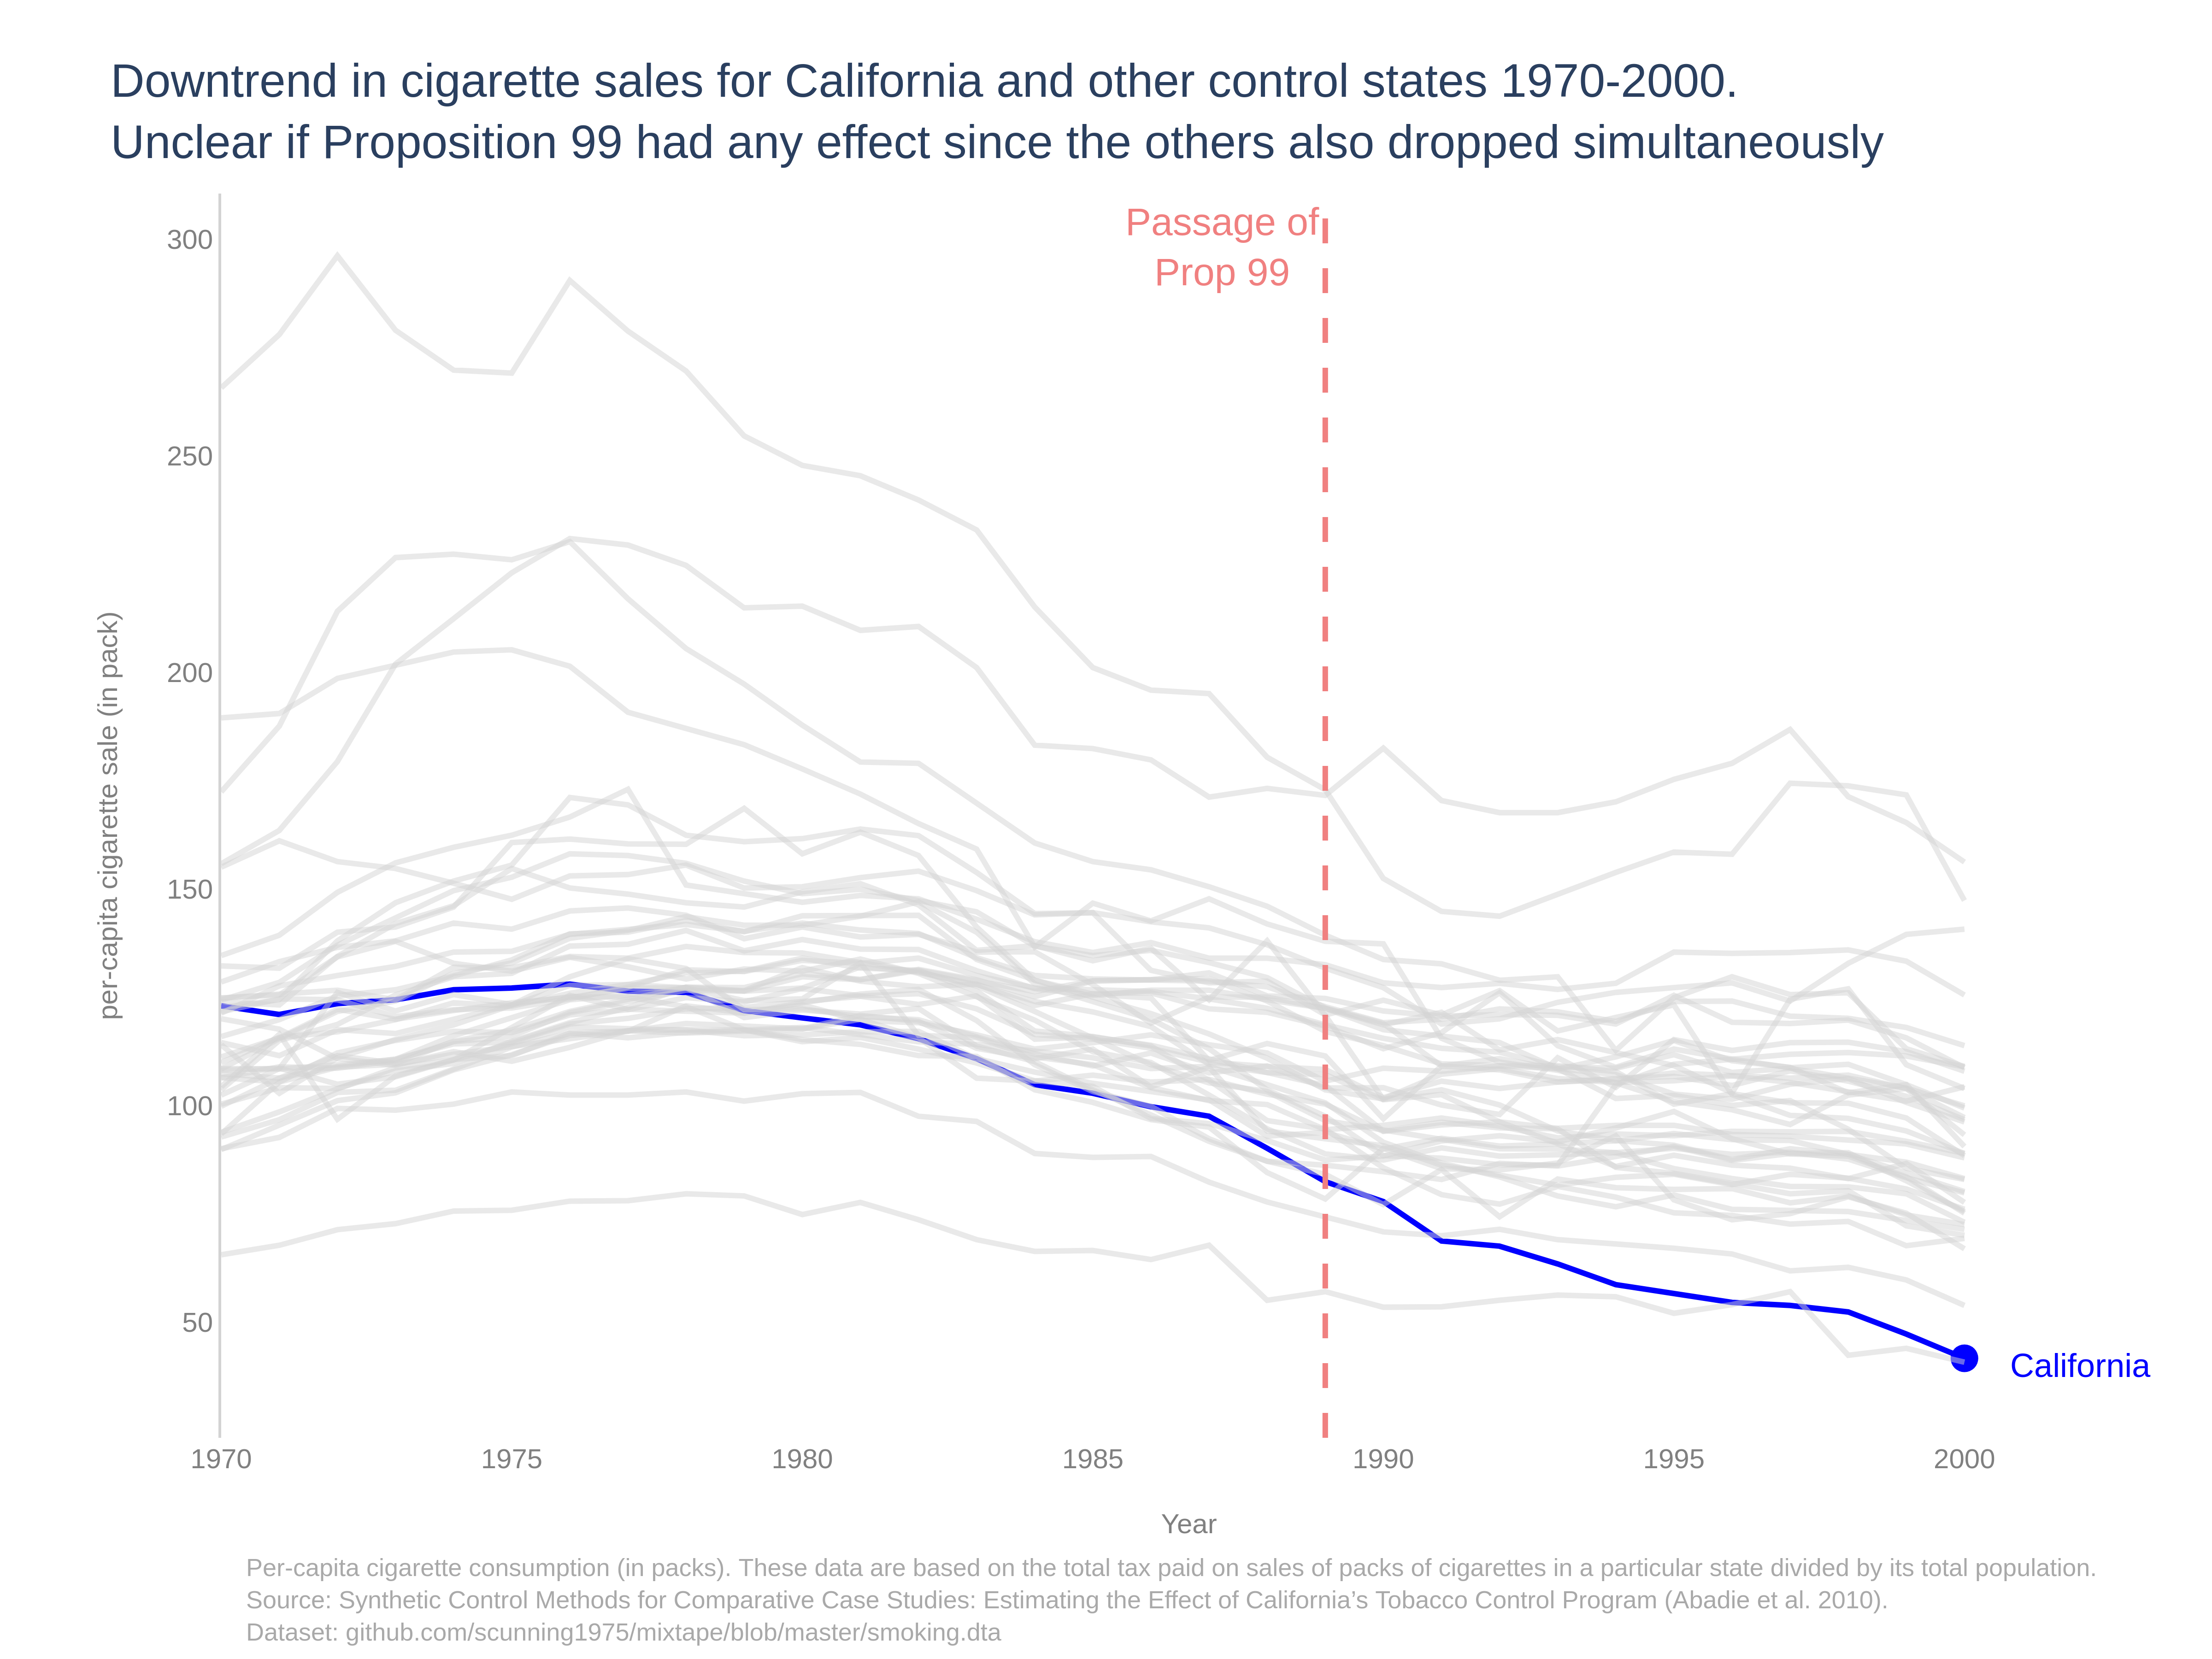

In [ ]:
Image(filename="prop99_overall_trend.png")

In [ ]:
def prepare_covariate(df: pd.DataFrame,
                      covariate_spec: Dict[str, Tuple[str, str, Tuple[int, int]]],
                      id_col: str = 'country',
                      time_col: str = 'year') -> pd.DataFrame:
    """
    Build the covariate matrix which can also affect the outcome of an ID

    Parameters
    ----------
    df : Original pd.DataFrame with columns: country, year, gdp, infrate, trade, schooling, invest60, invest70, invest80, industry
    covariate_spec : Covariate calculation specifications
    id_col : Unit identifier column (country)
    time_col : Time column (year)

    Returns
    -------
    cov_df : Covariate pd.DataFrame with countries as rows, covariates as columns
    """


    cov_list = list(covariate_spec.keys())
    cov_rows = []

    # Build covariates for each ID

    for unit, grp in df.groupby(id_col):
        row = {id_col: unit}
        for cov_name, (col, agg_method, yrs) in covariate_spec.items():
            if isinstance(yrs, tuple):  # average over interval
                start, end = yrs
                vals = grp[(grp[time_col] >= start) & (grp[time_col] <= end)][col]
                row[cov_name] = vals.agg(agg_method) if not vals.empty else np.nan
            elif isinstance(yrs, list):  # average over point-wise
                start, end = yrs
                vals = grp[grp[time_col].isin([start, end])][col]
                row[cov_name] = vals.agg(agg_method) if not vals.empty else np.nan
            else:  # single year
                vals = grp[grp[time_col] == yrs][col]
                row[cov_name] = vals.iloc[0] if not vals.empty else np.nan
        cov_rows.append(row)

    return pd.DataFrame(cov_rows).set_index(id_col)

In [ ]:
time_col, id_col, outcome_col = 'year', 'state', 'cigsale'
treated_unit, treatment_year = 'California', 1988
df_pivot = df.pivot(index=time_col, columns=id_col, values=outcome_col).sort_index()
display(df_pivot.head(5))
# Covariate Specification which can affect CA cig sales
covariate_spec = {
    'lnincome_avg': ('lnincome', 'mean', (1980, treatment_year)),     # Ln(GDP per capita)
    'age15to24_avg': ('age15to24', 'mean', (1980, treatment_year)),   # Percent aged 15–24
    'retprice_avg': ('retprice', 'mean', (1980, treatment_year)),     # Retail price
    'beer_avg': ('beer', 'mean', (1984, treatment_year)),             # Beer Consumption per capita
    'cigsale_1988': ('cigsale', '', treatment_year),              # Cigarette sales per capita 1988
    'cigsale_1980': ('cigsale', '', 1980),              # Cigarette sales per capita 1980
    'cigsale_1975': ('cigsale', '', 1975),              # Cigarette sales per capita 1975
}

cov_df = prepare_covariate(df, covariate_spec, id_col=id_col, time_col=time_col)
display(cov_df)

state,Alabama,Arkansas,California,Colorado,Connecticut,Delaware,Georgia,Idaho,Illinois,Indiana,...,South Carolina,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,West Virginia,Wisconsin,Wyoming
year,,,,,,,,,,,,,,,,,,,,,
1970.0,89.800003,100.300003,123.000000,124.800003,120.000000,155.000000,109.900002,102.400002,124.800003,134.600006,...,103.599998,92.699997,99.800003,106.400002,65.500000,122.599998,124.300003,114.500000,106.400002,132.199997
1971.0,95.400002,104.099998,121.000000,125.500000,117.599998,161.100006,115.699997,108.500000,125.599998,139.300003,...,115.000000,96.699997,106.300003,108.900002,67.699997,124.400002,128.399994,111.500000,105.400002,131.699997
1972.0,101.099998,103.900002,123.500000,134.300003,110.800003,156.300003,117.000000,126.099998,126.599998,149.199997,...,118.699997,103.000000,111.500000,108.599998,71.300003,138.000000,137.000000,117.500000,108.800003,140.000000
1973.0,102.900002,108.000000,124.400002,137.899994,109.300003,154.699997,119.800003,121.800003,124.400002,156.000000,...,125.500000,103.500000,109.699997,110.400002,72.699997,146.800003,143.100006,116.599998,109.500000,141.199997
1974.0,108.199997,109.699997,126.699997,132.800003,112.400002,151.300003,123.699997,125.599998,131.899994,159.600006,...,129.699997,108.400002,114.800003,114.699997,75.599998,151.800003,149.600006,119.900002,111.800003,145.800003


<ipython-input-6-2349871565>:26: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,lnincome_avg,age15to24_avg,retprice_avg,beer_avg,cigsale_1988,cigsale_1980,cigsale_1975
state,,,,,,,
Alabama,9.678974,17.480190,89.344444,18.960001,112.099998,123.199997,111.699997
Arkansas,9.643623,16.461138,89.877777,18.520000,121.500000,131.800003,114.800003
California,10.076558,17.353237,89.422226,24.279999,90.099998,120.199997,127.099998
Colorado,9.984357,17.370323,82.622223,25.079998,94.599998,131.000000,131.000000
Connecticut,10.188035,16.365971,103.477776,20.700001,104.800003,118.000000,110.199997
Delaware,9.974561,17.822451,90.055550,26.080002,137.100006,150.500000,147.600006
Georgia,9.817173,17.694412,84.366669,21.759998,124.099998,134.000000,122.900002
Idaho,9.711302,15.201672,86.077789,22.219999,84.500000,115.199997,123.300003
Illinois,10.006884,17.028118,89.833336,24.740002,107.599998,135.199997,131.800003


In [ ]:
def synthetic_control_method(df: pd.DataFrame,
                             cov_df: pd.DataFrame,
                             treated_unit: str,
                             treatment_year: int,
                             ftol: float = 1e-6,
                             method: str = 'SLSQP',
                             verbose: bool = False) -> Tuple[pd.DataFrame, Dict, np.array]:
    """
    Run synthetic control by finding optimal weights between treated unit and the others (donors)

    Parameters
    ----------
    df : GDP by years by countries, (index = years, columns: GDP of each non-treated countries (donors)). Original data must be pivoted
    cov_df : Pre-computed covariate pd.DataFrame above
    treated_unit : str Treatment country (i.e. West Germany)
    treatment_year : int Treatment year
    ftol: float Precision goal for the value of f in the stopping criterion.
    method : str Scipy Optimization method
    verbose : bool Print diagnostics

    Returns
    -------
    synth_df : Synthetic control pd.DataFrame results
    w_opt : dict of donor weights
    v_opt : Covariate weights np.ndarray
    """

    # Define pre-treatment period
    pre_mask = df.index < treatment_year

    # Extract treated and control outcomes
    Y_tr = df.loc[pre_mask, treated_unit].values
    Y_co = df.loc[pre_mask].drop(columns=[treated_unit]).values

    # Extract covariates to matrix
    cov_list = cov_df.columns.tolist()
    Z_tr = cov_df.loc[treated_unit].values
    Z_co = cov_df.drop(index=treated_unit).values

    # Need to Normalize covariates to [0,1]

    Z_mean = Z_co.mean(axis=0)
    Z_std = Z_co.std(axis=0)
    Z_std = np.where(Z_std == 0, 1e-6, Z_std)  # Avoid divide by zero

    Z_tr = (Z_tr - Z_mean) / Z_std
    Z_co = (Z_co - Z_mean[np.newaxis, :]) / Z_std[np.newaxis, :]


    J = Z_co.shape[0]  # number of donors
    p = Z_co.shape[1]  # number of covariates

    # Optimize W given V
    def synth_w_from_v(v):
        V = np.diag(v)
        def obj_w(w):
            d = Z_tr - Z_co.T.dot(w)
            return d.T.dot(V).dot(d)
        cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
        bounds = [(0, 1)] * J

        # Initial guess for W
        # We have 38 states, so it's not efficient to assume uniform weights across 38 units
        # We use Ridge regression to fit between covariates of treatment and control to initialize the weights

        from sklearn.linear_model import Ridge
        model = Ridge(alpha=0.1, positive=True, fit_intercept=True)
        model.fit(Z_co.T, Z_tr)

        # Take absolute value of coefficients (importance measure)
        coef_importance = np.abs(model.coef_)
        w0 = coef_importance / coef_importance.sum()

        res = minimize(obj_w, w0, bounds=bounds, constraints=cons, method=method, tol=ftol)
        return res.x

    # Optimize V to match the outcome
    def outer_obj(v):
        w = synth_w_from_v(v)
        resid = Y_tr - Y_co.dot(w)
        return np.sum(resid**2)

    cons_v = ({'type': 'eq', 'fun': lambda v: np.sum(v) - 1},)
    bounds_v = [(0, 1)] * p

    # Initial guess for V: Uniform
    v0 = np.ones(p) / p

    res_v = minimize(outer_obj, v0, bounds=bounds_v, constraints=cons_v, method=method, tol=ftol)

    v_opt = res_v.x
    w_vec = synth_w_from_v(v_opt)

    # Map weights back to donor units
    donors = [u for u in df.columns if u != treated_unit]
    w_opt = dict(zip(donors, w_vec))

    cov_list = cov_df.columns.tolist()
    v_opt = dict(zip(cov_list, v_opt))

    if verbose:
        print(f"Country: {treated_unit}")
        print("Optimal V:", v_opt)
        print("Top 3 donor weights:", sorted(w_opt.items(), key=lambda x: x[1], reverse=True)[:3])

    # Construct synthetic series
    synth_vals = df.drop(columns=[treated_unit]).values.dot(w_vec)

    synth_df = pd.DataFrame({
        'year': df.index,
        'Treated': df[treated_unit].values,
        'Synthetic': synth_vals,
        'Gap': df[treated_unit].values - synth_vals
    })

    return synth_df, w_opt, v_opt

In [ ]:
synth_df, w_opt, v_opt = synthetic_control_method(df_pivot, cov_df, treated_unit, treatment_year)#, method='trust-constr') #L-BFGS-B
synth_df_ca = synth_df.copy()
weight_table = pd.DataFrame({
    'Donor Unit': list(w_opt.keys()),
    'Weight': list(w_opt.values())
}).sort_values(by='Weight', ascending=False)
weight_table['Weight'] = weight_table['Weight'].round(4)
print("\nDonor Weights Table:")
print(weight_table.to_markdown(index=False))
v_table = pd.DataFrame({
    'Variable': list(v_opt.keys()),
    'Weight': list(v_opt.values())
}).sort_values(by='Weight', ascending=False)
print("Vartiable Weights Table:")
print(v_table.to_markdown(index=False))


Donor Weights Table:
| Donor Unit     |   Weight |
|:---------------|---------:|
| Utah           |   0.3316 |
| Nevada         |   0.2267 |
| Colorado       |   0.1972 |
| Montana        |   0.1723 |
| Connecticut    |   0.0721 |
| Minnesota      |   0      |
| New Mexico     |   0      |
| Iowa           |   0      |
| Virginia       |   0      |
| North Carolina |   0      |
| Maine          |   0      |
| Delaware       |   0      |
| West Virginia  |   0      |
| Texas          |   0      |
| Oklahoma       |   0      |
| Arkansas       |   0      |
| Nebraska       |   0      |
| Wisconsin      |   0      |
| South Dakota   |   0      |
| Georgia        |   0      |
| Kentucky       |   0      |
| South Carolina |   0      |
| Missouri       |   0      |
| Alabama        |   0      |
| Kansas         |   0      |
| Mississippi    |   0      |
| Indiana        |   0      |
| Illinois       |   0      |
| Louisiana      |   0      |
| Idaho          |   0      |
| New Hampshire  |

**`California = 0.33 x Utah + 0.23 x Nevada + 0.2 x Colorado + 0.17 x Montana + 0.07 x Connecticut`**


In [ ]:
model_weights = weight_table[weight_table.Weight > 0]


reference_weights = {
    'Utah': 0.334,
    'Nevada': 0.234,
    'Montana': 0.199,
    'Colorado': 0.164,
    'Connecticut': 0.069
}

for d in model_weights['Donor Unit'].unique():
  if d not in reference_weights.keys():
    reference_weights[d] = 0



weight_plot = pd.DataFrame({
    'State': list(model_weights['Donor Unit'].unique()),
    'Model': list(model_weights['Weight']),
    'Reference': [reference_weights[state] for state in list(model_weights['Donor Unit'].unique())]
})
display(weight_plot)


fig = go.Figure()


fig.add_trace(go.Bar(
    x=weight_plot['State'],
    y=weight_plot['Model'],
    # width=0.45,
    name='Our Model',
    marker_color='blue'
))


fig.add_trace(go.Bar(
    x=weight_plot['State'],
    y=weight_plot['Reference'],
    # width=0.45,
    name='Abadie et. al. (2010)',
    marker_color='lightgrey'
))

fig.update_xaxes(
    showgrid=False,
    linecolor='grey',
    tickfont=dict(color='grey', size=10),
    tickcolor='grey',
    title='State',
    title_font=dict(color='grey', size=10, family=font),

)

fig.update_yaxes(
    showgrid=False,
    title='Weight',
    linecolor='grey',
    tickfont=dict(color='grey', size=10),
    title_font=dict(color='grey', size=10, family=font),
    tickcolor='grey',
)


fig.update_layout(
    title='Comparison of Donor Weights by States: Our model vs. Abadie et. al. (2010)<br>Our weights are generally close to the reference values (only few minor differences)',
    barmode='group',
    width=800,
    height=400,
    legend=dict(
        x=-0.03,
        y=0.99,
        traceorder='normal',
        orientation='h',
        xanchor='left',
        yanchor='bottom',
    ),
    margin=dict(t=130, r=10, b=5, l=50),
    template='plotly_white'
)

# fig.update_traces(width=0.2)

fig.show()
fig.write_image("prop99_weight_comparison.png", scale=6)

,State,Model,Reference
0,Utah,0.3316,0.334
1,Nevada,0.2267,0.234
2,Colorado,0.1972,0.164
3,Montana,0.1723,0.199
4,Connecticut,0.0721,0.069


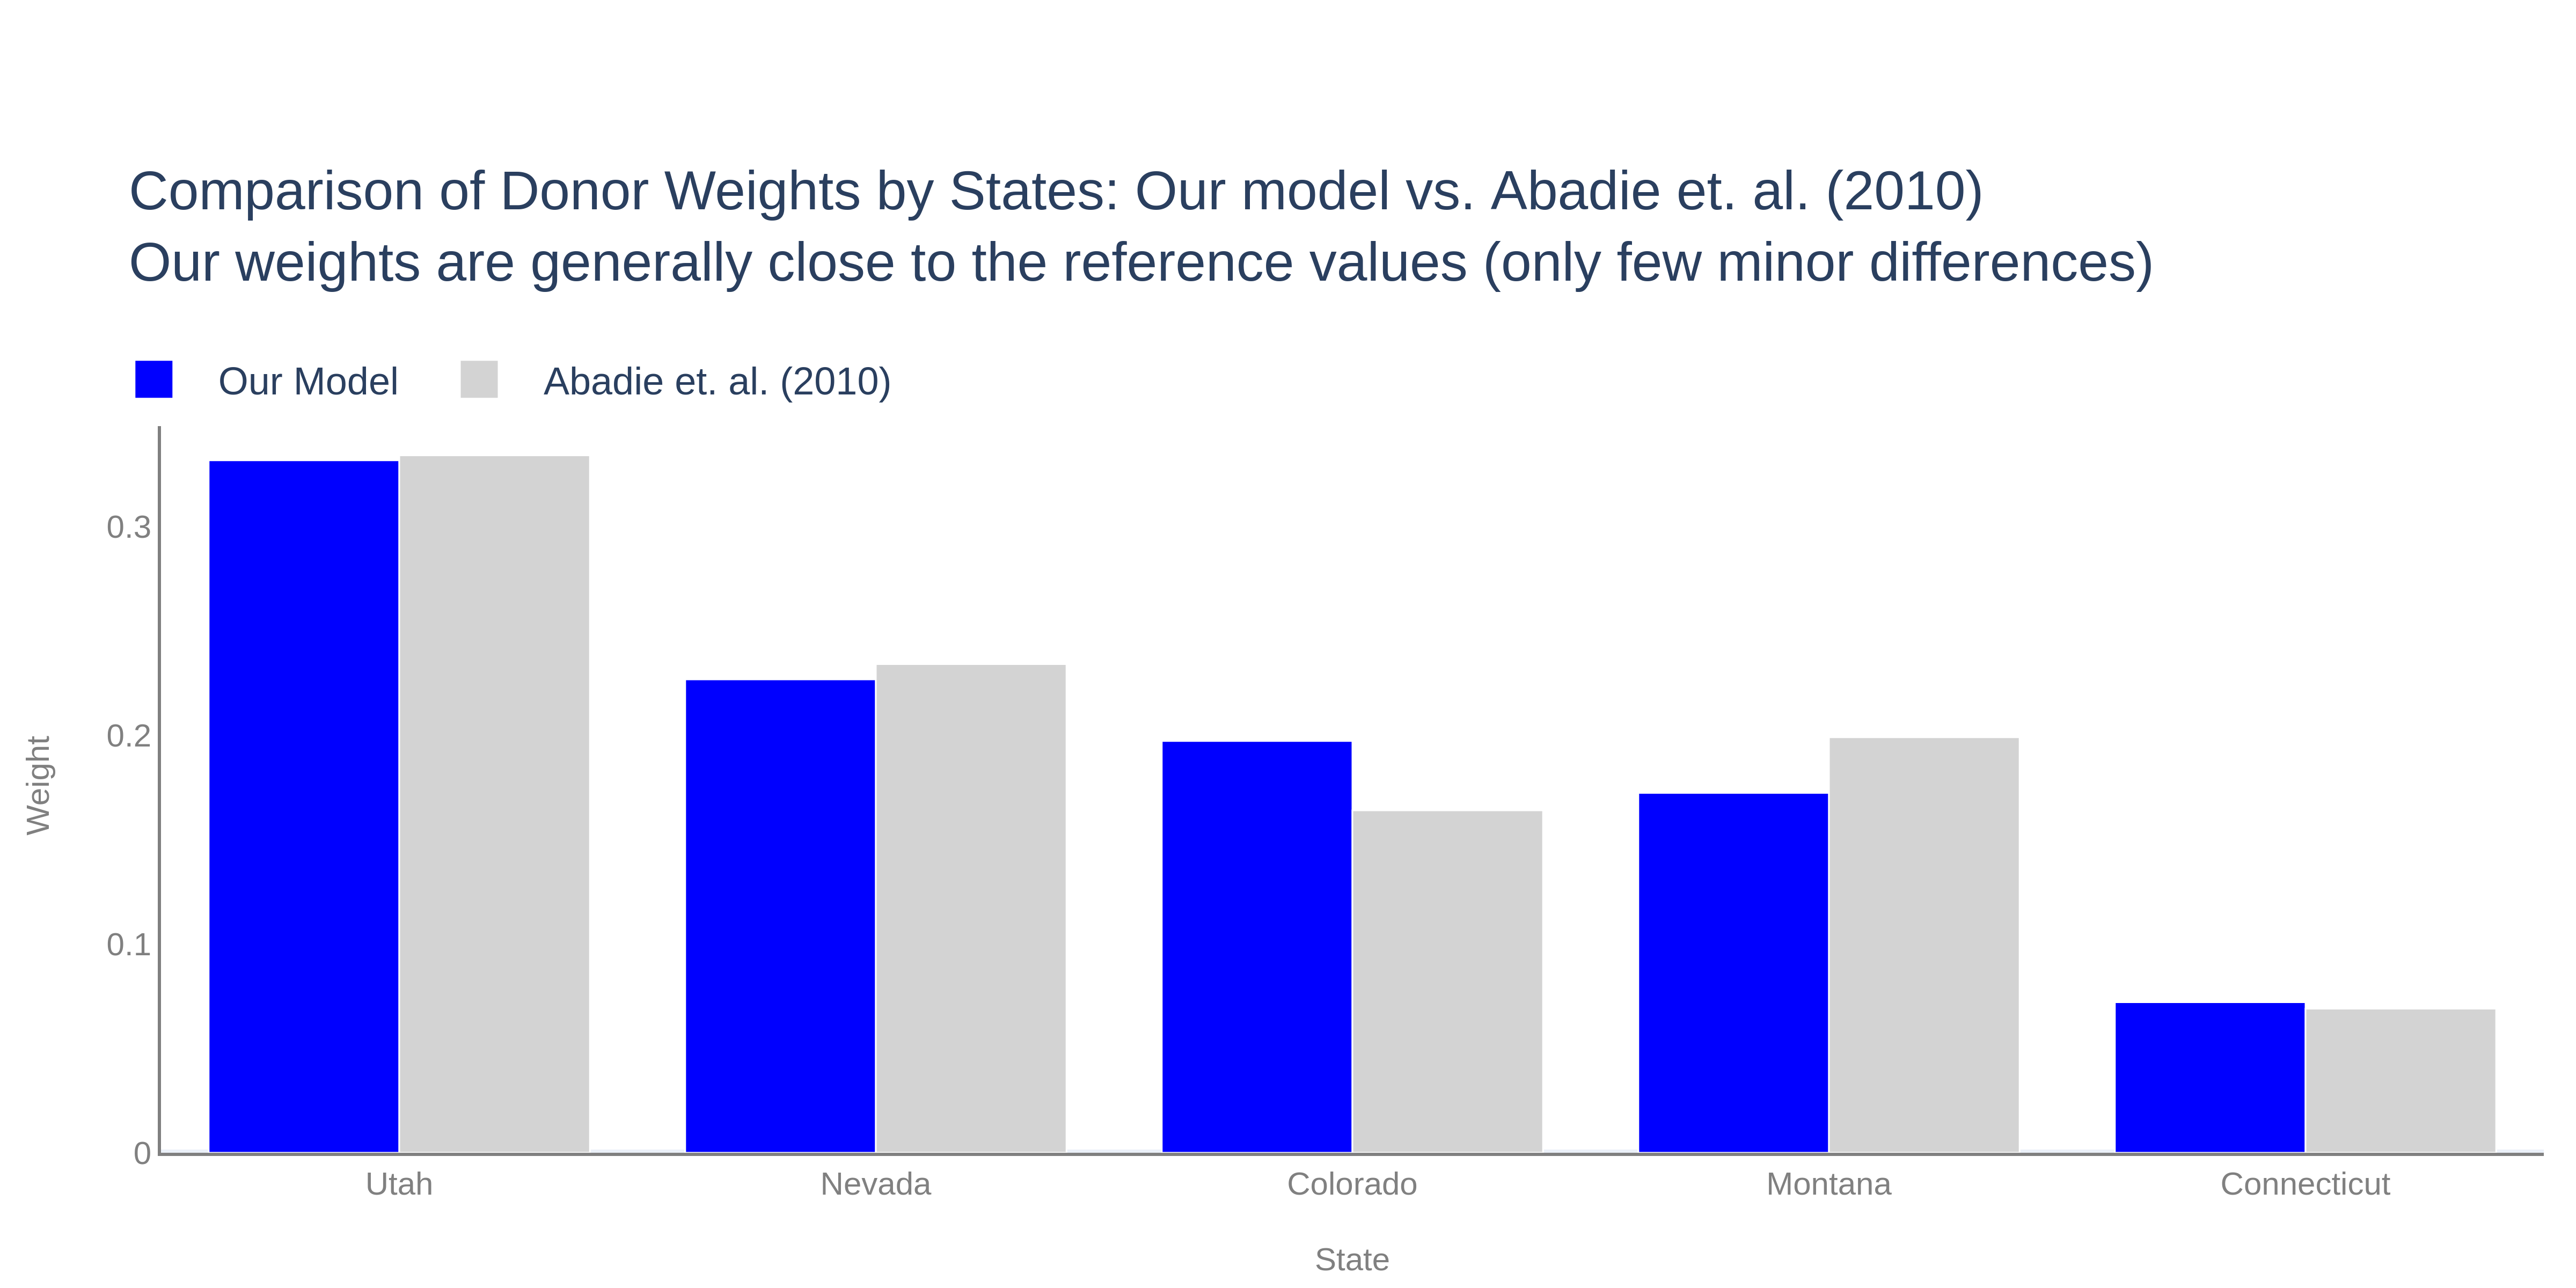

In [ ]:
Image(filename="prop99_weight_comparison.png")

In [ ]:
# Variable name mappings for prettier output
var_name_map = {
  'lnincome_avg': 'Ln(GDP per capita)',
  'age15to24_avg': 'Percent aged 15–24',
  'retprice_avg':'Retail price',
  'beer_avg': 'Beer consumption per capita',
  'cigsale_1988': 'Cigarette sales per capita 1988',
  'cigsale_1980': 'Cigarette sales per capita 1980',
  'cigsale_1975': 'Cigarette sales per capita 1975',
}
title="Balance table. All Predictor Means before Passage of Proposition 99."
length_table=80

# Get donor units and their weights
donor_units = [unit for unit in cov_df.index if unit != treated_unit]
weights = np.array([w_opt.get(unit, 0) for unit in donor_units])

# Calculate values
treated_values = cov_df.loc[treated_unit]
donor_matrix = cov_df.loc[donor_units].values
synthetic_values = donor_matrix.T @ weights  # Weighted average of donors
control_avg = cov_df.loc[donor_units].mean()  # Simple average of all donors

# Print table header
print(f"\n{title}")
print("=" * length_table)
print(f"{'':40}  {treated_unit:>15}            Average of")
print(f"{'Variables':40} {'(Real)':>8} {'(Synthetic)':>9}  {len(donor_units)} other states")
print(f"{'':40} {'':>8} {'':>9}")
print("-" * length_table)

# Print each variable
for i, (var_code, var_val) in enumerate(treated_values.items()):
    # Get pretty variable name
    var_name = var_name_map.get(var_code, var_code)

    # Values
    real_val = var_val
    synthetic_val = synthetic_values[i]
    control_val = control_avg[var_code]

    # Format based on variable type
    if 'rate' in var_code.lower() or 'share' in var_code.lower():
        real_str = f"{real_val:.2f}"
        synth_str = f"{synthetic_val:.2f}"
        control_str = f"{control_val:.2f}"
    elif 'gdp' in var_code:
        real_str = f"{real_val:.0f}"
        synth_str = f"{synthetic_val:.0f}"
        control_str = f"{control_val:.0f}"
    else:
        real_str = f"{real_val:.2f}"
        synth_str = f"{synthetic_val:.2f}"
        control_str = f"{control_val:.2f}"

    print(f"{var_name:40} {real_str:>8} {synth_str:>9} {control_str:>15}")

print("=" * length_table)

# Add note about time periods
print("\nNOTE: All variables except lagged cigarette sales are averaged for 1980–1988")
print("      Beer consumption is averaged 1984–1988.")
# print("for the 1980–85 period.")


Balance table. All Predictor Means before Passage of Proposition 99.
                                               California            Average of
Variables                                  (Real) (Synthetic)  38 other states
                                                           
--------------------------------------------------------------------------------
Ln(GDP per capita)                          10.08      9.87            9.83
Percent aged 15–24                          17.35     17.38           17.25
Retail price                                89.42     89.30           87.27
Beer consumption per capita                 24.28     24.06           23.66
Cigarette sales per capita 1988             90.10     91.63          113.82
Cigarette sales per capita 1980            120.20    120.46          138.09
Cigarette sales per capita 1975            127.10    126.76          136.93

NOTE: All variables except lagged cigarette sales are averaged for 1980–1988
      Beer consumpti

The balance table's characteristics and outcomes also look similar to the references. Synthetic California matches its real version closely compared to simply averaging other states.

In [ ]:
print(synth_df_ca[synth_df_ca.year > treatment_year]['Gap'].mean())
fig = make_subplots(rows=2, cols=1,
                    row_heights=[0.7, 0.3],
                    shared_xaxes=True,
                    vertical_spacing=0.05)

fig.add_trace(go.Scatter(x=synth_df['year'], y=synth_df['Treated'],
                         mode='lines', name='Treated',
                         line=dict(color='blue'), showlegend=False),
              row=1, col=1)

fig.add_trace(go.Scatter(x=[2000], y=[synth_df[synth_df['year'] == 2000]['Treated'].iloc[0]],
                    mode='markers', marker=dict(color='blue', size=10), showlegend=False))

fig.add_trace(go.Scatter(x=synth_df['year'], y=synth_df['Synthetic'],
                         mode='lines', name='Synthetic',
                         opacity=0.5, line=dict(color='rgba(0, 0, 255, 0.85)', dash="dash"), showlegend=False),
              row=1, col=1)
fig.add_trace(go.Scatter(x=[2000], y=[synth_df[synth_df['year'] == 2000]['Synthetic'].iloc[0]], opacity=0.5,
                    mode='markers', marker=dict(color='rgba(0, 0, 255, 0.85)', size=10, symbol='circle-open-dot'), showlegend=False))


fig.add_annotation(x=2001.5, y=synth_df[synth_df['year'] == 2000]['Treated'].iloc[0], text="California",
                   font=dict(family=font, color='blue'), showarrow=False,
                   row=1, col=1)

fig.add_annotation(x=2001.5, y=synth_df[synth_df['year'] == 2000]['Synthetic'].iloc[0]*0.95, text="Synthetic<br>California",
                   font=dict(family=font, color='rgba(0, 0, 255, 0.85)'),
                   opacity=0.5, showarrow=False,
                   row=1, col=1)

fig.add_vline(x=treatment_year, line=dict(color="lightcoral", width=2, dash="dash"),
              annotation_text="Passage of<br>Prop 99", annotation_position="top left",
              annotation_font=dict(color="lightcoral", size=14, family=font),
              row=1, col=1)

fig.update_yaxes(
    # title_text='Per Capita GDP (PPP, 2002 US$)',
    title_font=dict(color='grey', size=10, family=font),
    showgrid=False,
    linecolor='grey',
    tickfont=dict(color='grey', size=10),
    tickcolor='grey',
    row=1, col=1
)

fig.update_xaxes(
    showgrid=False,
    row=1, col=1
)


fig.add_trace(go.Scatter(x=synth_df['year'], y=synth_df['Gap'],
                         mode='lines', name='Gap',
                         line=dict(color='grey'), showlegend=False),
              row=2, col=1)


fig.add_vline(x=treatment_year, line=dict(color="lightcoral", width=2, dash="dash"),
              row=2, col=1)

fig.add_hline(y=0, line=dict(color="grey", width=0.5, dash="dot"),
              row=2, col=1)

fig.update_xaxes(
    showgrid=False,
    linecolor='grey',
    tickfont=dict(color='grey', size=10),
    tickcolor='grey',
    title_text='Year',
    title_font=dict(color='grey', size=10, family=font),
    row=2, col=1
)


fig.update_yaxes(
    title_text='per-capita cigarette sale<br>(in pack)',
    title_font=dict(color='grey', size=10, family=font),
    showgrid=False,
    linecolor='grey',
    tickfont=dict(color='grey', size=10),
    tickcolor='grey',
    row=1, col=1
)

fig.update_yaxes(
    title_text='Gap<br>in per-capita cigarette sale<br>(in pack)',
    title_font=dict(color='grey', size=10, family=font),
    showgrid=False,
    linecolor='grey',
    tickfont=dict(color='grey', size=10),
    tickcolor='grey',
    row=2, col=1
)
fig.update_layout(
    title=dict(
        text="""At first sight, Proposition 99 seems effective.<br>Before 1989, the synthetic closely mirrored California's smoking habits.<br>Once Proposition 99 passed, they dramatically diverged.""",
        font=dict(size=16, family=font, color='grey'),
        x=0.015,
        xanchor='left'
    ),
    # yaxis_tickprefix='$',
    template='plotly_white',
    height=700, width=800,
    margin=dict(t=100, r=20, b=15),
)

fig.show()
fig.write_image("CA_synthetic_vs_real.png", scale=6)

-18.83085408202611


* Before 1989, our synthetic California almost perfectly mirrored the real California's smoking habits. The moment Proposition 99 passes, the two lines diverge dramatically.
* After 1989, while the synthetic, law-free California continued its gentle decline, the real California significantly fell. The gap between the real and the synthetic represents the impact of the law, which also appeared to grow stronger over time during that decade.
* We can estimate how many cigarettes would have been sold in California after 1989 if Proposition 99 had never existed, averaging ~20 fewer packs per person per year.

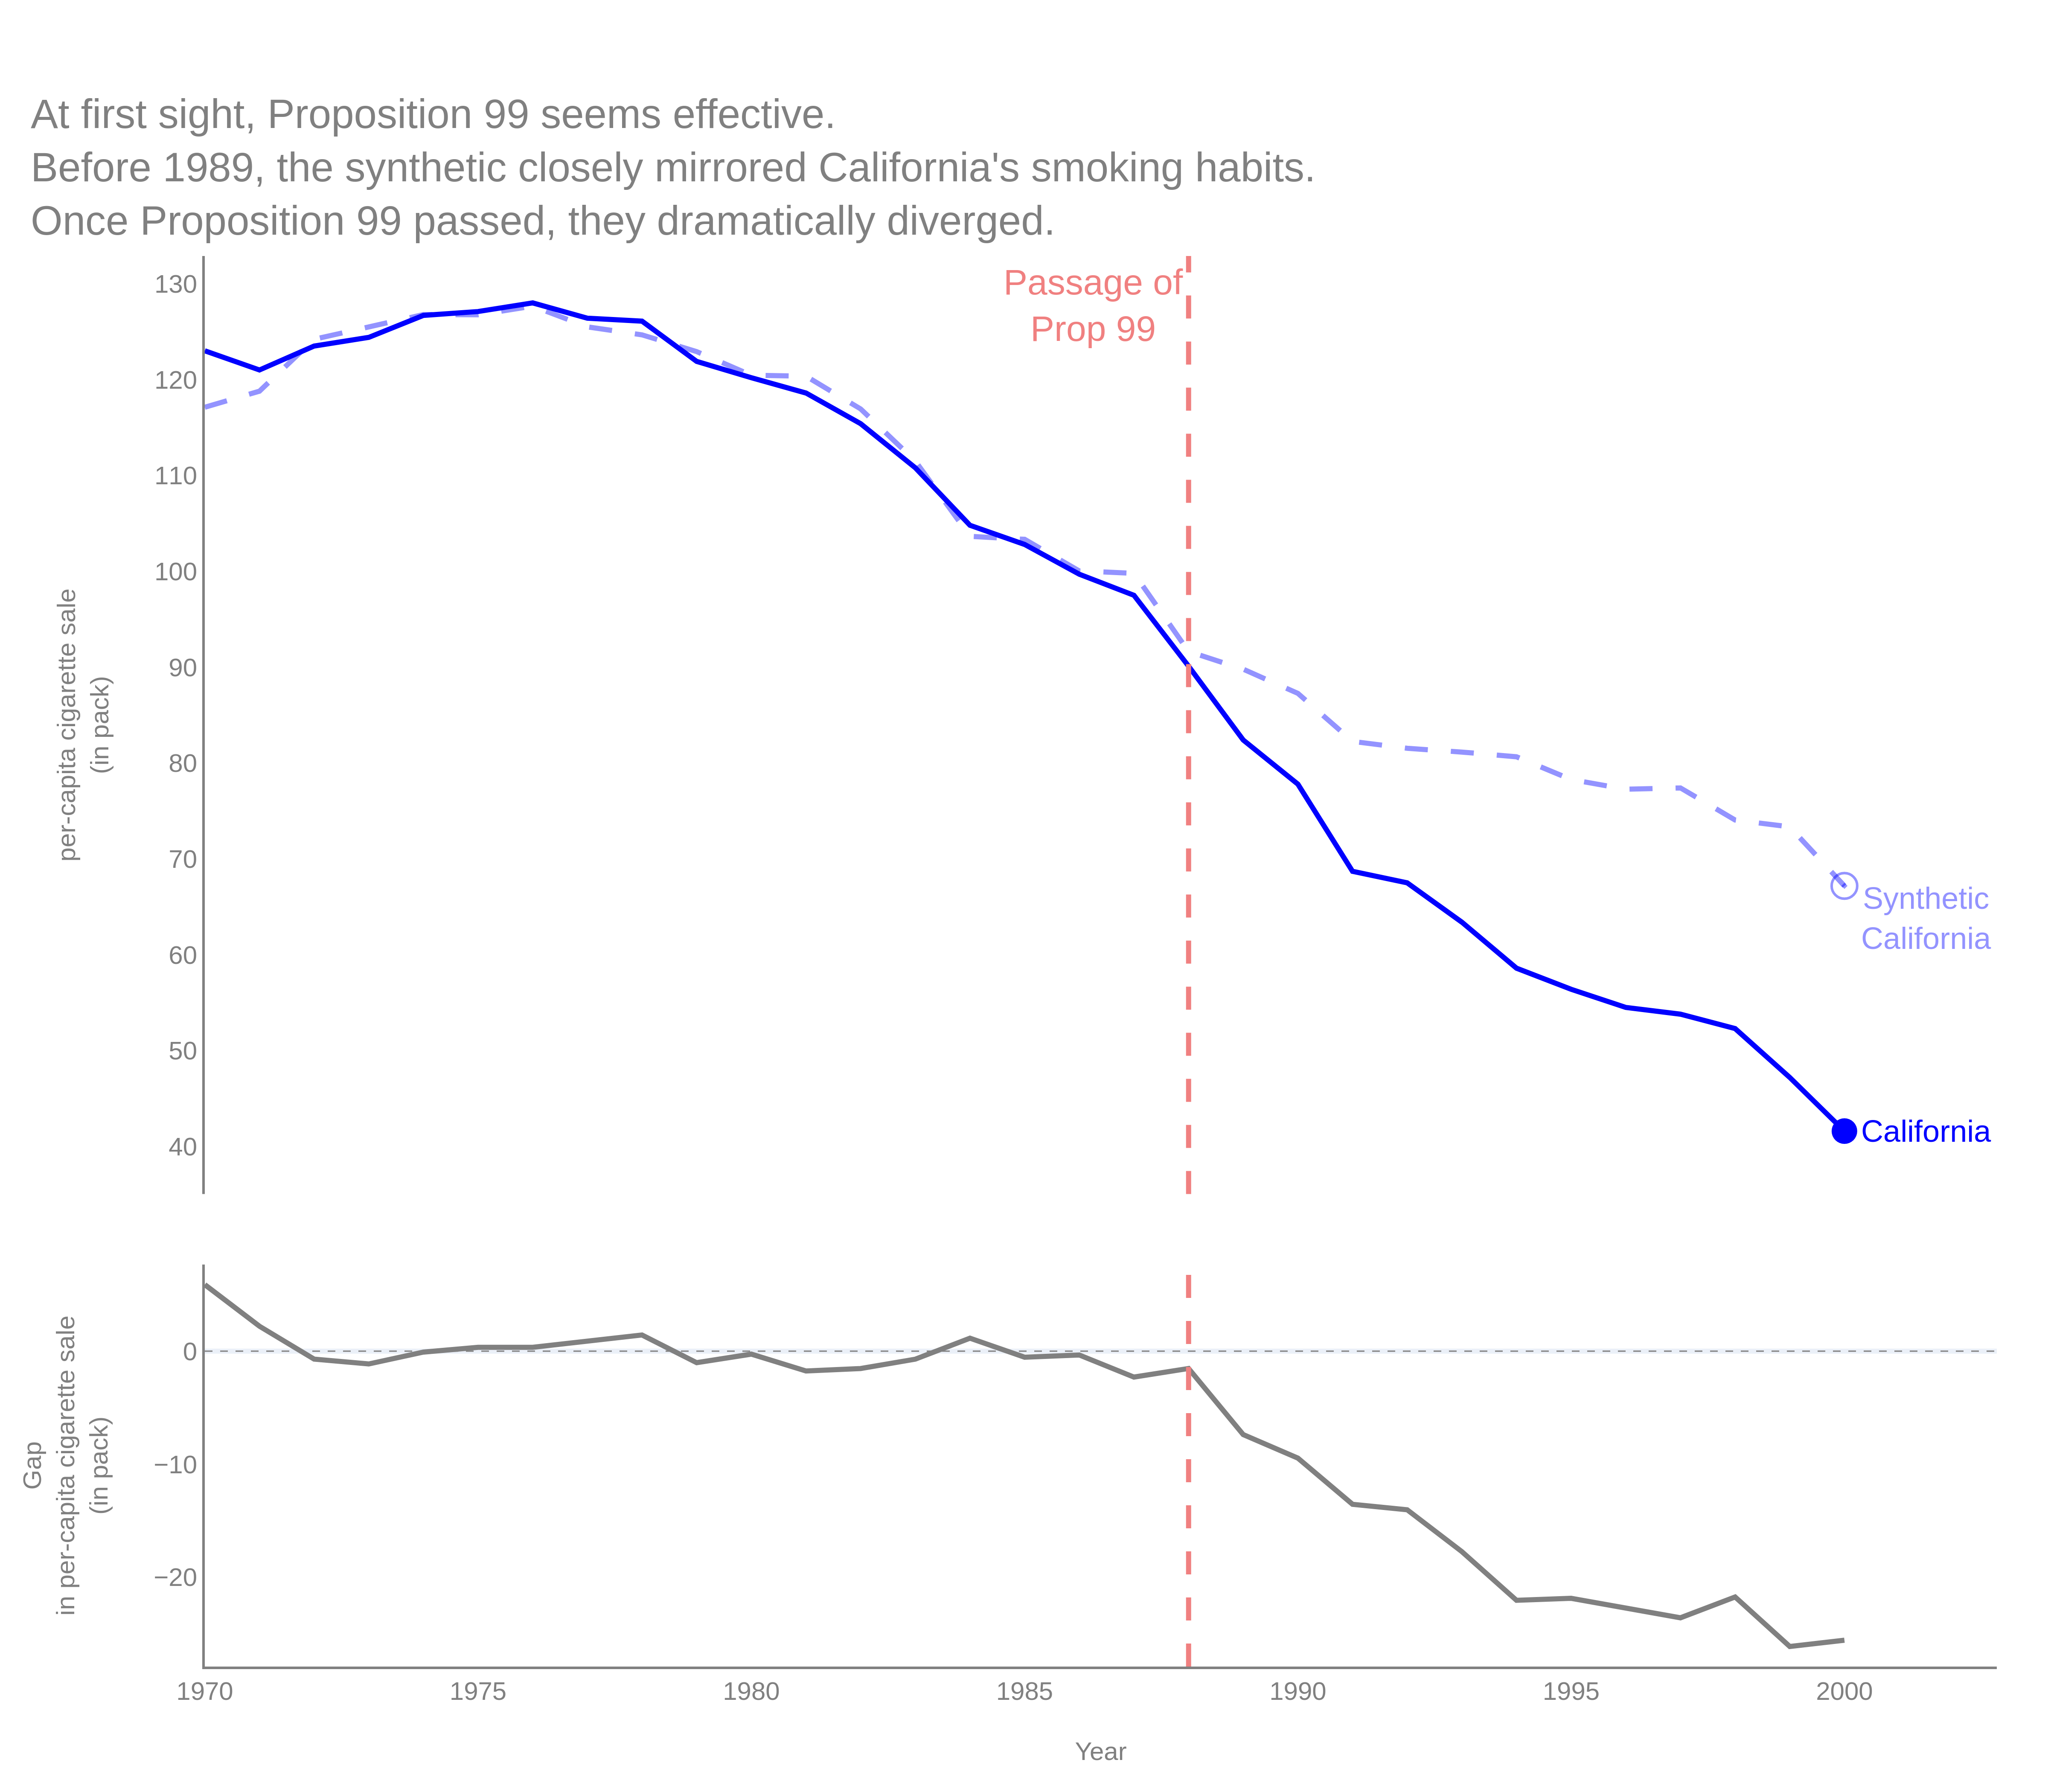

In [ ]:
Image(filename="CA_synthetic_vs_real.png")

## PLACEBO STUDIES

In [ ]:
def run_placebo_tests(df: pd.DataFrame,
                      cov_df: pd.DataFrame,
                      treated_unit: str,
                      treatment_year: int,
                      outcome_col: str = 'gdp',
                      id_col: str = 'country',
                      time_col: str = 'year',
                      method: str = 'SLSQP',
                      verbose: bool = False) -> Dict:

    """
    Run placebo tests efficiently by pre-computing covariates once.

    Parameters
    ----------
    df : pd.DataFrame with original data
    cov_df : pd.DataFrame Covariate specifications
    treated_unit : str treatment unit ('West Germany')
    treatment_year : int Treatment year
    outcome_col : str, Outcome variable (gdp)
    id_col : str Unit ID (country)
    time_col : str Time identifier (year)
    method : str Scipy Optimization method

    Returns
    -------
    placebo_results : dict Store results for each placebo unit
    """

    Y_pivot = df.pivot(index=time_col, columns=id_col, values=outcome_col).sort_index()

    print("Start running placebo tests...")

    placebo_units = Y_pivot.columns.tolist()

    placebo_results = {}

    for i, unit in enumerate(placebo_units):
        print(f"  Placebo {i+1}/{len(placebo_units)}: {unit}")

        try:
            synth_df, w_opt, v_opt = synthetic_control_method(Y_pivot, cov_df, unit, treatment_year, method=method, verbose=verbose)

            # pre-treatment RMSPE
            pre_mask = synth_df['year'] < treatment_year
            pre_gap = synth_df.loc[pre_mask, 'Gap']
            pre_rmspe = np.sqrt(np.mean(pre_gap**2))

            # post-treatment RMSPE
            post_mask = synth_df['year'] >= treatment_year
            post_gap = synth_df.loc[post_mask, 'Gap']
            post_rmspe = np.sqrt(np.mean(post_gap**2))

            post_pre_rmspe_ratio = post_rmspe / pre_rmspe if pre_rmspe > 0 else np.inf

            placebo_results[unit] = {
                'synth_df': synth_df,
                'weights': w_opt,
                'v_weights': v_opt,
                'pre_rmspe': pre_rmspe,
                'post_rmspe': post_rmspe,
                'post_pre_rmspe_ratio': post_pre_rmspe_ratio
            }

        except Exception as e:
            print(f"    Failed for {unit}: {e}")
            continue

    print(f"Completed {len(placebo_results)} placebo tests.")

    print("\nPost and Pre RMSPE Ratio:")
    rmspe_summary = [(unit, res['post_pre_rmspe_ratio']) for unit, res in placebo_results.items()]
    rmspe_summary.sort(key=lambda x: x[1])

    for unit, rmspe in rmspe_summary:
        marker = " <-- TRUE TREATED" if unit == treated_unit else ""
        print(f"  {unit:20}: {rmspe:.4f}{marker}")

    return placebo_results

In [ ]:
placebo_results = run_placebo_tests(df, cov_df, id_col=id_col, outcome_col=outcome_col, treated_unit='California', treatment_year=treatment_year)#, method='trust-constr')

Start running placebo tests...
  Placebo 1/39: Alabama
  Placebo 2/39: Arkansas
  Placebo 3/39: California
  Placebo 4/39: Colorado
  Placebo 5/39: Connecticut
  Placebo 6/39: Delaware
  Placebo 7/39: Georgia
  Placebo 8/39: Idaho
  Placebo 9/39: Illinois
  Placebo 10/39: Indiana
  Placebo 11/39: Iowa
  Placebo 12/39: Kansas
  Placebo 13/39: Kentucky
  Placebo 14/39: Louisiana
  Placebo 15/39: Maine
  Placebo 16/39: Minnesota
  Placebo 17/39: Mississippi
  Placebo 18/39: Missouri
  Placebo 19/39: Montana
  Placebo 20/39: Nebraska
  Placebo 21/39: Nevada
  Placebo 22/39: New Hampshire
  Placebo 23/39: New Mexico
  Placebo 24/39: North Carolina
  Placebo 25/39: North Dakota
  Placebo 26/39: Ohio
  Placebo 27/39: Oklahoma
  Placebo 28/39: Pennsylvania
  Placebo 29/39: Rhode Island
  Placebo 30/39: South Carolina
  Placebo 31/39: South Dakota
  Placebo 32/39: Tennessee
  Placebo 33/39: Texas
  Placebo 34/39: Utah
  Placebo 35/39: Vermont
  Placebo 36/39: Virginia
  Placebo 37/39: West Virg

In [ ]:
from plotly.subplots import make_subplots

sorted_results = sorted(placebo_results.items(), key=lambda x: x[1]['post_pre_rmspe_ratio'], reverse=False)
units = [unit for unit, res in sorted_results]
ratios = [res['post_pre_rmspe_ratio'] for unit, res in sorted_results]

colors = []
for i in range(len(ratios)):
    if i == len(ratios) - 1:
        colors.append('rgba(0, 0, 255, 1.0)')
    elif i == len(ratios) - 2:
        colors.append('rgba(0, 0, 255, 0.8)')
    elif i == len(ratios) - 3:
        colors.append('rgba(0, 0, 255, 0.6)')
    elif i == len(ratios) - 4:
        colors.append('rgba(0, 0, 255, 0.4)')
    elif i == len(ratios) - 5:
        colors.append('rgba(0, 0, 255, 0.2)')
    else:
        colors.append('lightgrey')

treated_ratio = placebo_results[treated_unit]['post_pre_rmspe_ratio'] if treated_unit in placebo_results else None


fig = make_subplots(rows=1, cols=2, subplot_titles=[
    "CA has the most extreme Post-/Pre- RMSPE ratio across placebo studies<br>Post-treatment gap ≅ 10 x pre-reunification gap",
    "Histogram distribution of Post-/Pre- RMSPE<br>across in-space placebo units"
])

# Bar
fig.add_trace(go.Bar(
    x=ratios,
    y=units,
    orientation='h',
    marker=dict(color=colors),
    name='Post/Pre RMSPE Ratio'
), row=1, col=1)


# Hist
treated_unit = 'California'
other_ratios = [r for u, r in zip(units, ratios) if u != treated_unit]

fig.add_trace(go.Histogram(
    x=other_ratios,
    nbinsx=10,
    marker=dict(color='lightgrey', line=dict(color='lightgrey', width=1)),
    name='Histogram of Ratios'
), row=1, col=2)

fig.add_trace(go.Bar(
    x=[treated_ratio],
    y=[1],
    marker=dict(color='rgba(0, 0, 255, 1.0)', line=dict(color='rgba(0, 0, 255, 1.0)', width=1)),
    name=f'{treated_unit} Ratio'
), row=1, col=2)

fig.add_annotation(x=treated_ratio*0.99,
                   y=1.25,
                   xref='x2', yref='y2',
                   text=f'{treated_unit}',
                   showarrow=True, arrowhead=2,
                   ax=-0, ay=-30, font=dict(color='blue', size=14, family=font))


fig.update_xaxes(title_text='Post-/Pre- RMSPE Ratio', row=1, col=1,  tickfont=dict(family=font, color='grey'), showgrid=False,
                 title_font=dict(color='grey', size=10, family=font),
                 linecolor='grey',
                 tickcolor='grey')

fig.update_yaxes(title_text='', row=1, col=1, tickfont=dict(family=font, color='black', size=10), showgrid=False)
fig.update_xaxes(title_text='Post-/Pre- RMSPE Ratio', row=1, col=2, tickfont=dict(family=font, color='grey'), showgrid=False,
                 title_font=dict(color='grey', size=10, family=font),
                 linecolor='grey',
                 tickcolor='grey'
                 )
fig.update_yaxes(title_text='Frequency', row=1, col=2,  tickfont=dict(family=font, color='grey',),  showgrid=False,
                 title_font=dict(color='grey', size=10, family=font),
                 linecolor='grey',
                 tickcolor='grey'
                 )


fig.update_layout(
    height=800,
    width=1200,
    template='plotly_white',
    showlegend=False,
    margin=dict(t=50, r=20, b=10),
)



fig.show()
fig.write_image("inspace_placebo.png", scale=6)

* When we consider all 39 states in our pool (California + 38 controls) with Post-/Pre-treatment RMSE ratio metrics, California has the most extreme values.
* The probability of any randomly chosen state showing an effect as significant as California's is even smaller: p-value = 1/39 ≈ 0.026. The result is not a random coincidence.

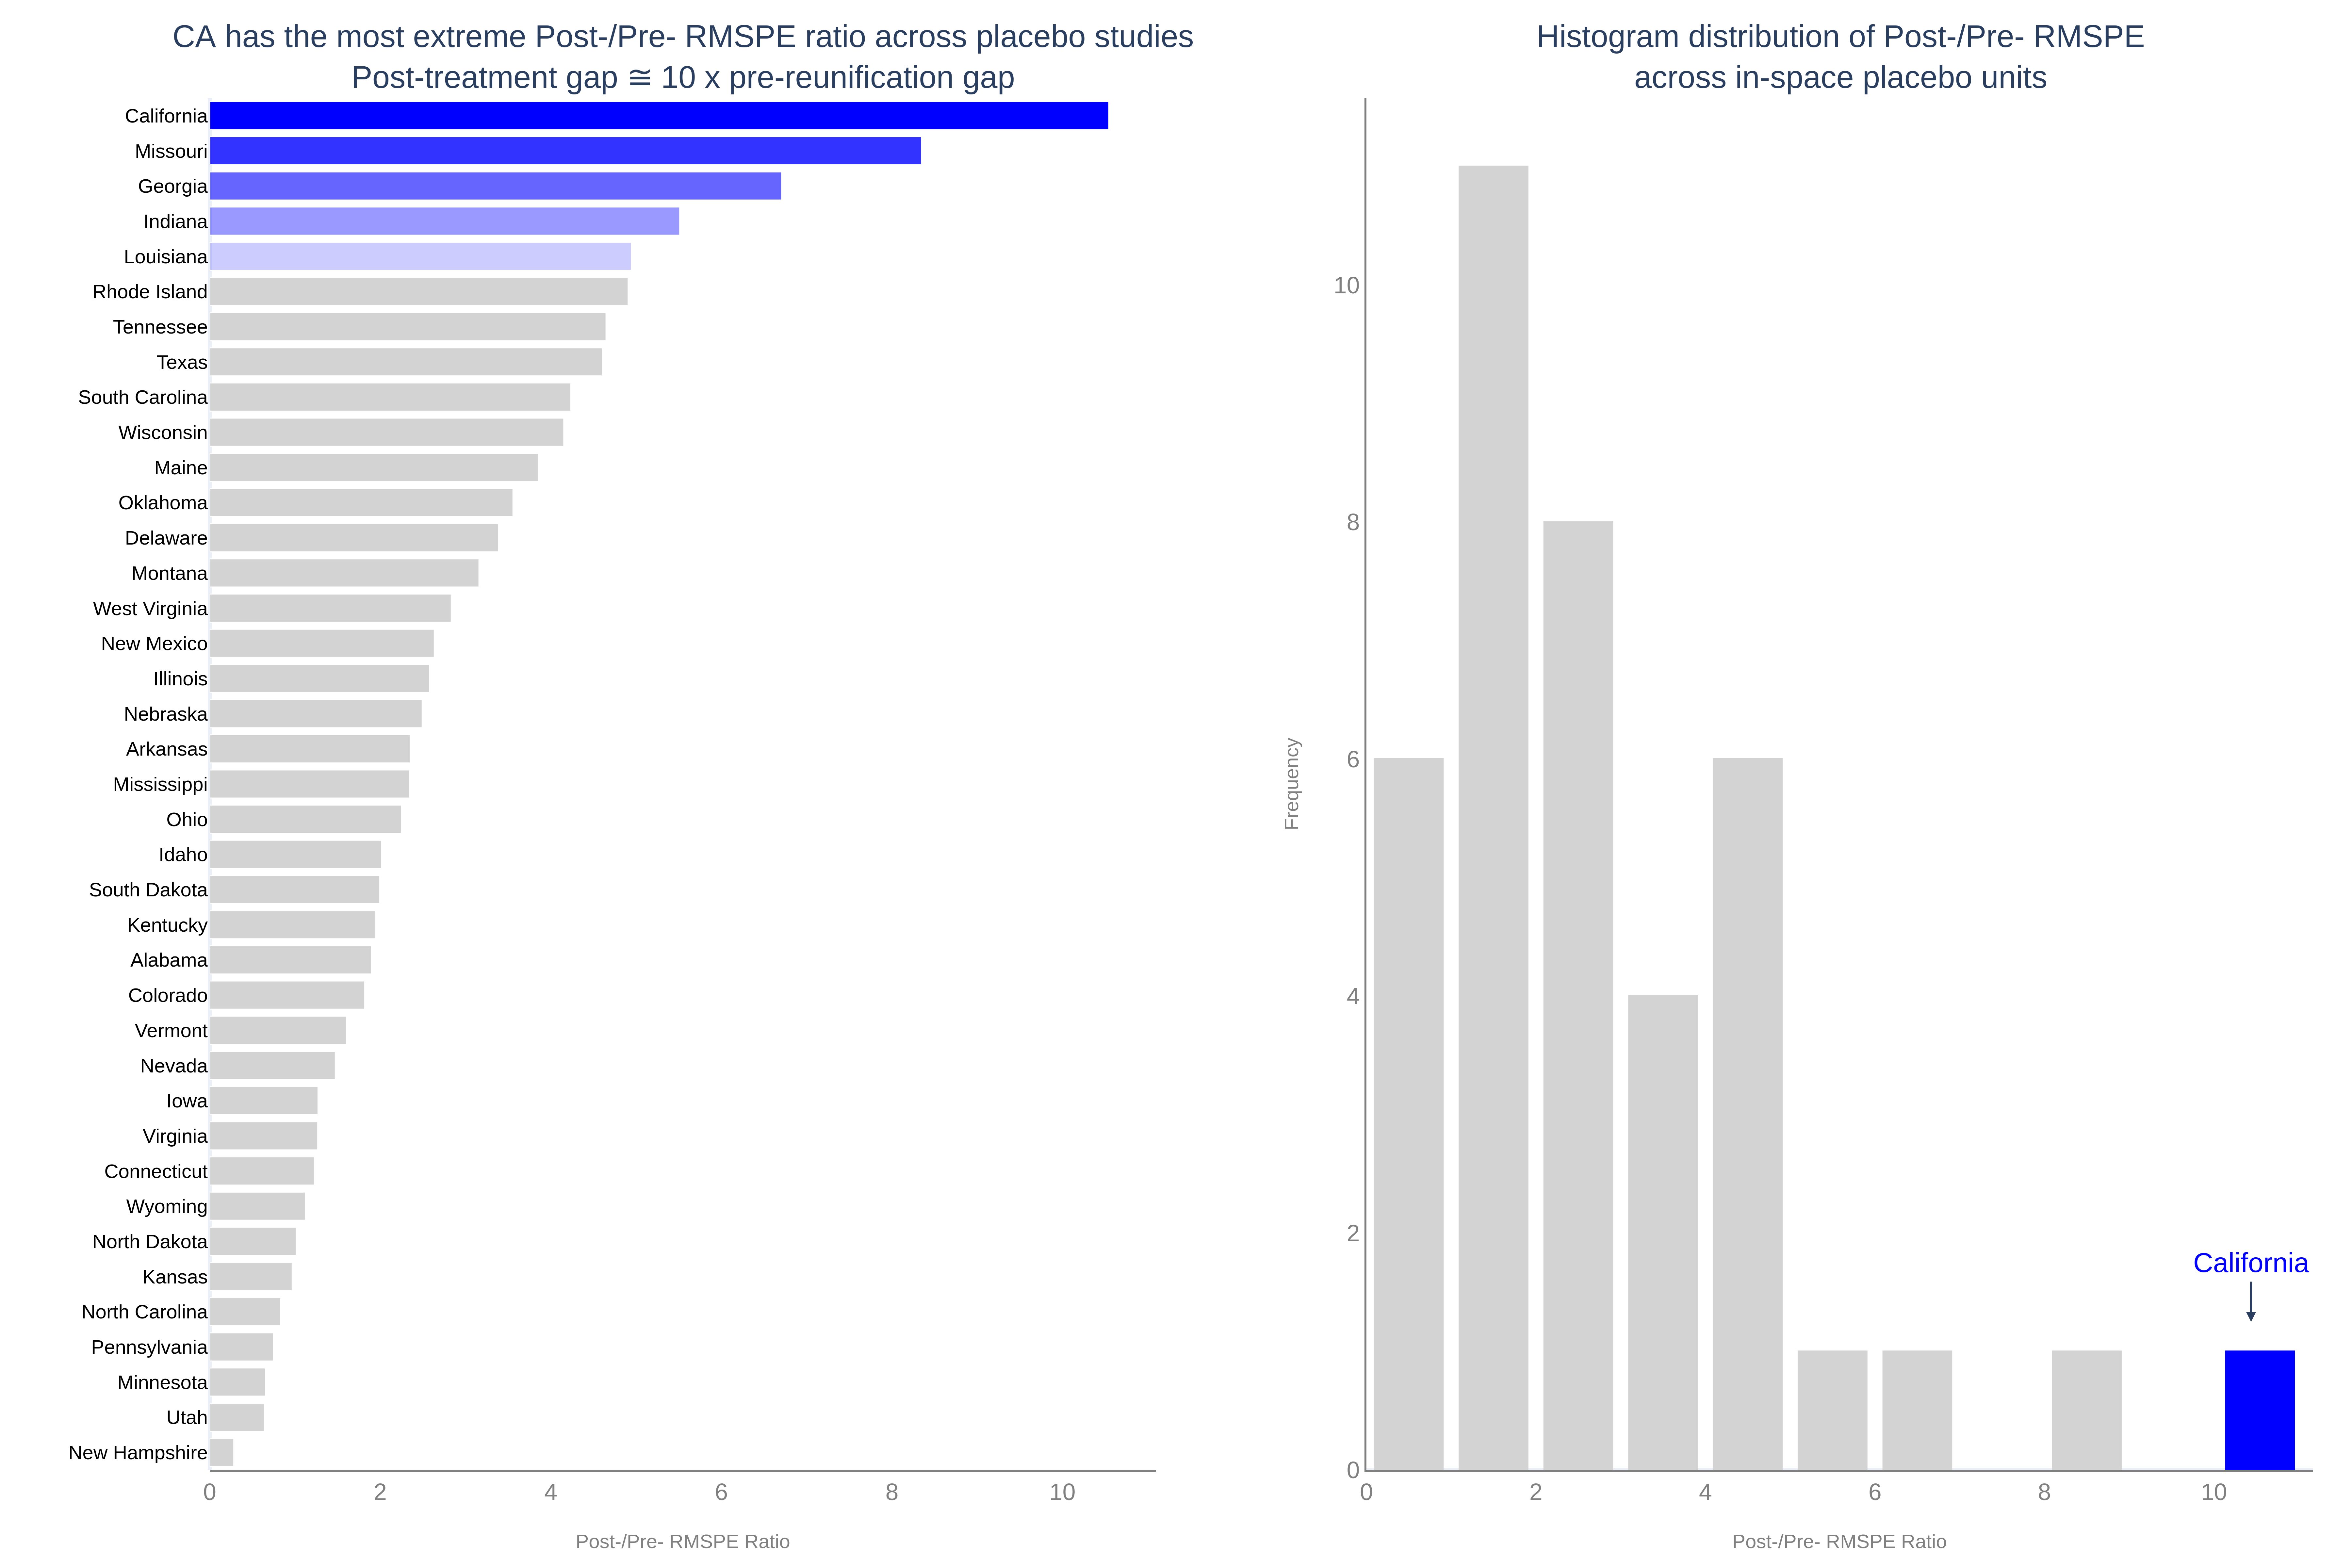

In [ ]:
Image(filename="inspace_placebo.png")

In [ ]:
fig = go.Figure()

states = df['state'].unique()
for state in states:
    state_data = placebo_results[state]['synth_df']
    if state == 'California':
        fig.add_trace(go.Scatter(x=state_data['year'], y=state_data['Gap'], mode='lines', name=state,
                                 line=dict(color='blue', width=5), showlegend=False))
        fig.add_trace(go.Scatter(x=[2000], y=[state_data[state_data['year'] == 2000]['Gap'].iloc[0]],
                    mode='markers', marker=dict(color='blue', size=10), showlegend=False))
        fig.add_annotation(x=2002, y=state_data[state_data['year'] == 2000]['Gap'].iloc[0],
                           text="California", font=dict(family=font, color='blue'), showarrow=False, arrowhead=1, arrowsize=1, arrowwidth=1, ax=20)

    else:
        fig.add_trace(go.Scatter(x=state_data['year'], y=state_data['Gap'], mode='lines', name=state, opacity=0.5,
                                 line=dict(color='lightgrey'), showlegend=False))


fig.add_vline(x=1989, line=dict(color="lightcoral", width=2, dash="dash")
              ,annotation_text="Prop 99", annotation_position="top right"
              ,annotation_font=dict(color="lightcoral", size=14, family=font))


fig.update_layout(
    title='All 38 placebo tests (pretend that other states   passed Prop 99, instead of CA)<br>The drop in cigarette sales in California after 1989 was extreme',
    xaxis_title='',
    yaxis_title='Gap between each state and its synthetic<br>in per-capita cigarette sale<br>(in pack)',
    # yaxis_tickprefix='$',
    template='plotly_white',
    height=500,width=800,
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False),
    margin=dict(t=70, r=5, b=10),
)

fig.update_xaxes(
    tickfont=dict(color='grey', size=10),
    tickcolor='grey',
    title_text='Year',
    title_font=dict(color='grey', size=10, family=font),
)

fig.update_yaxes(

    title_font=dict(color='grey', size=10, family=font),
    showgrid=False,
    linecolor='lightgrey',
    tickfont=dict(color='grey', size=10),
    tickcolor='grey',
)

# Show plot
fig.show()
fig.write_image("full_placebo_studies.png", scale=6)

All gray lines represent the difference in cigarette sales per person between the 38 "fake" intervention states and their made-up "synthetic" versions. The blue line shows this same difference for California, which was in distribution tails

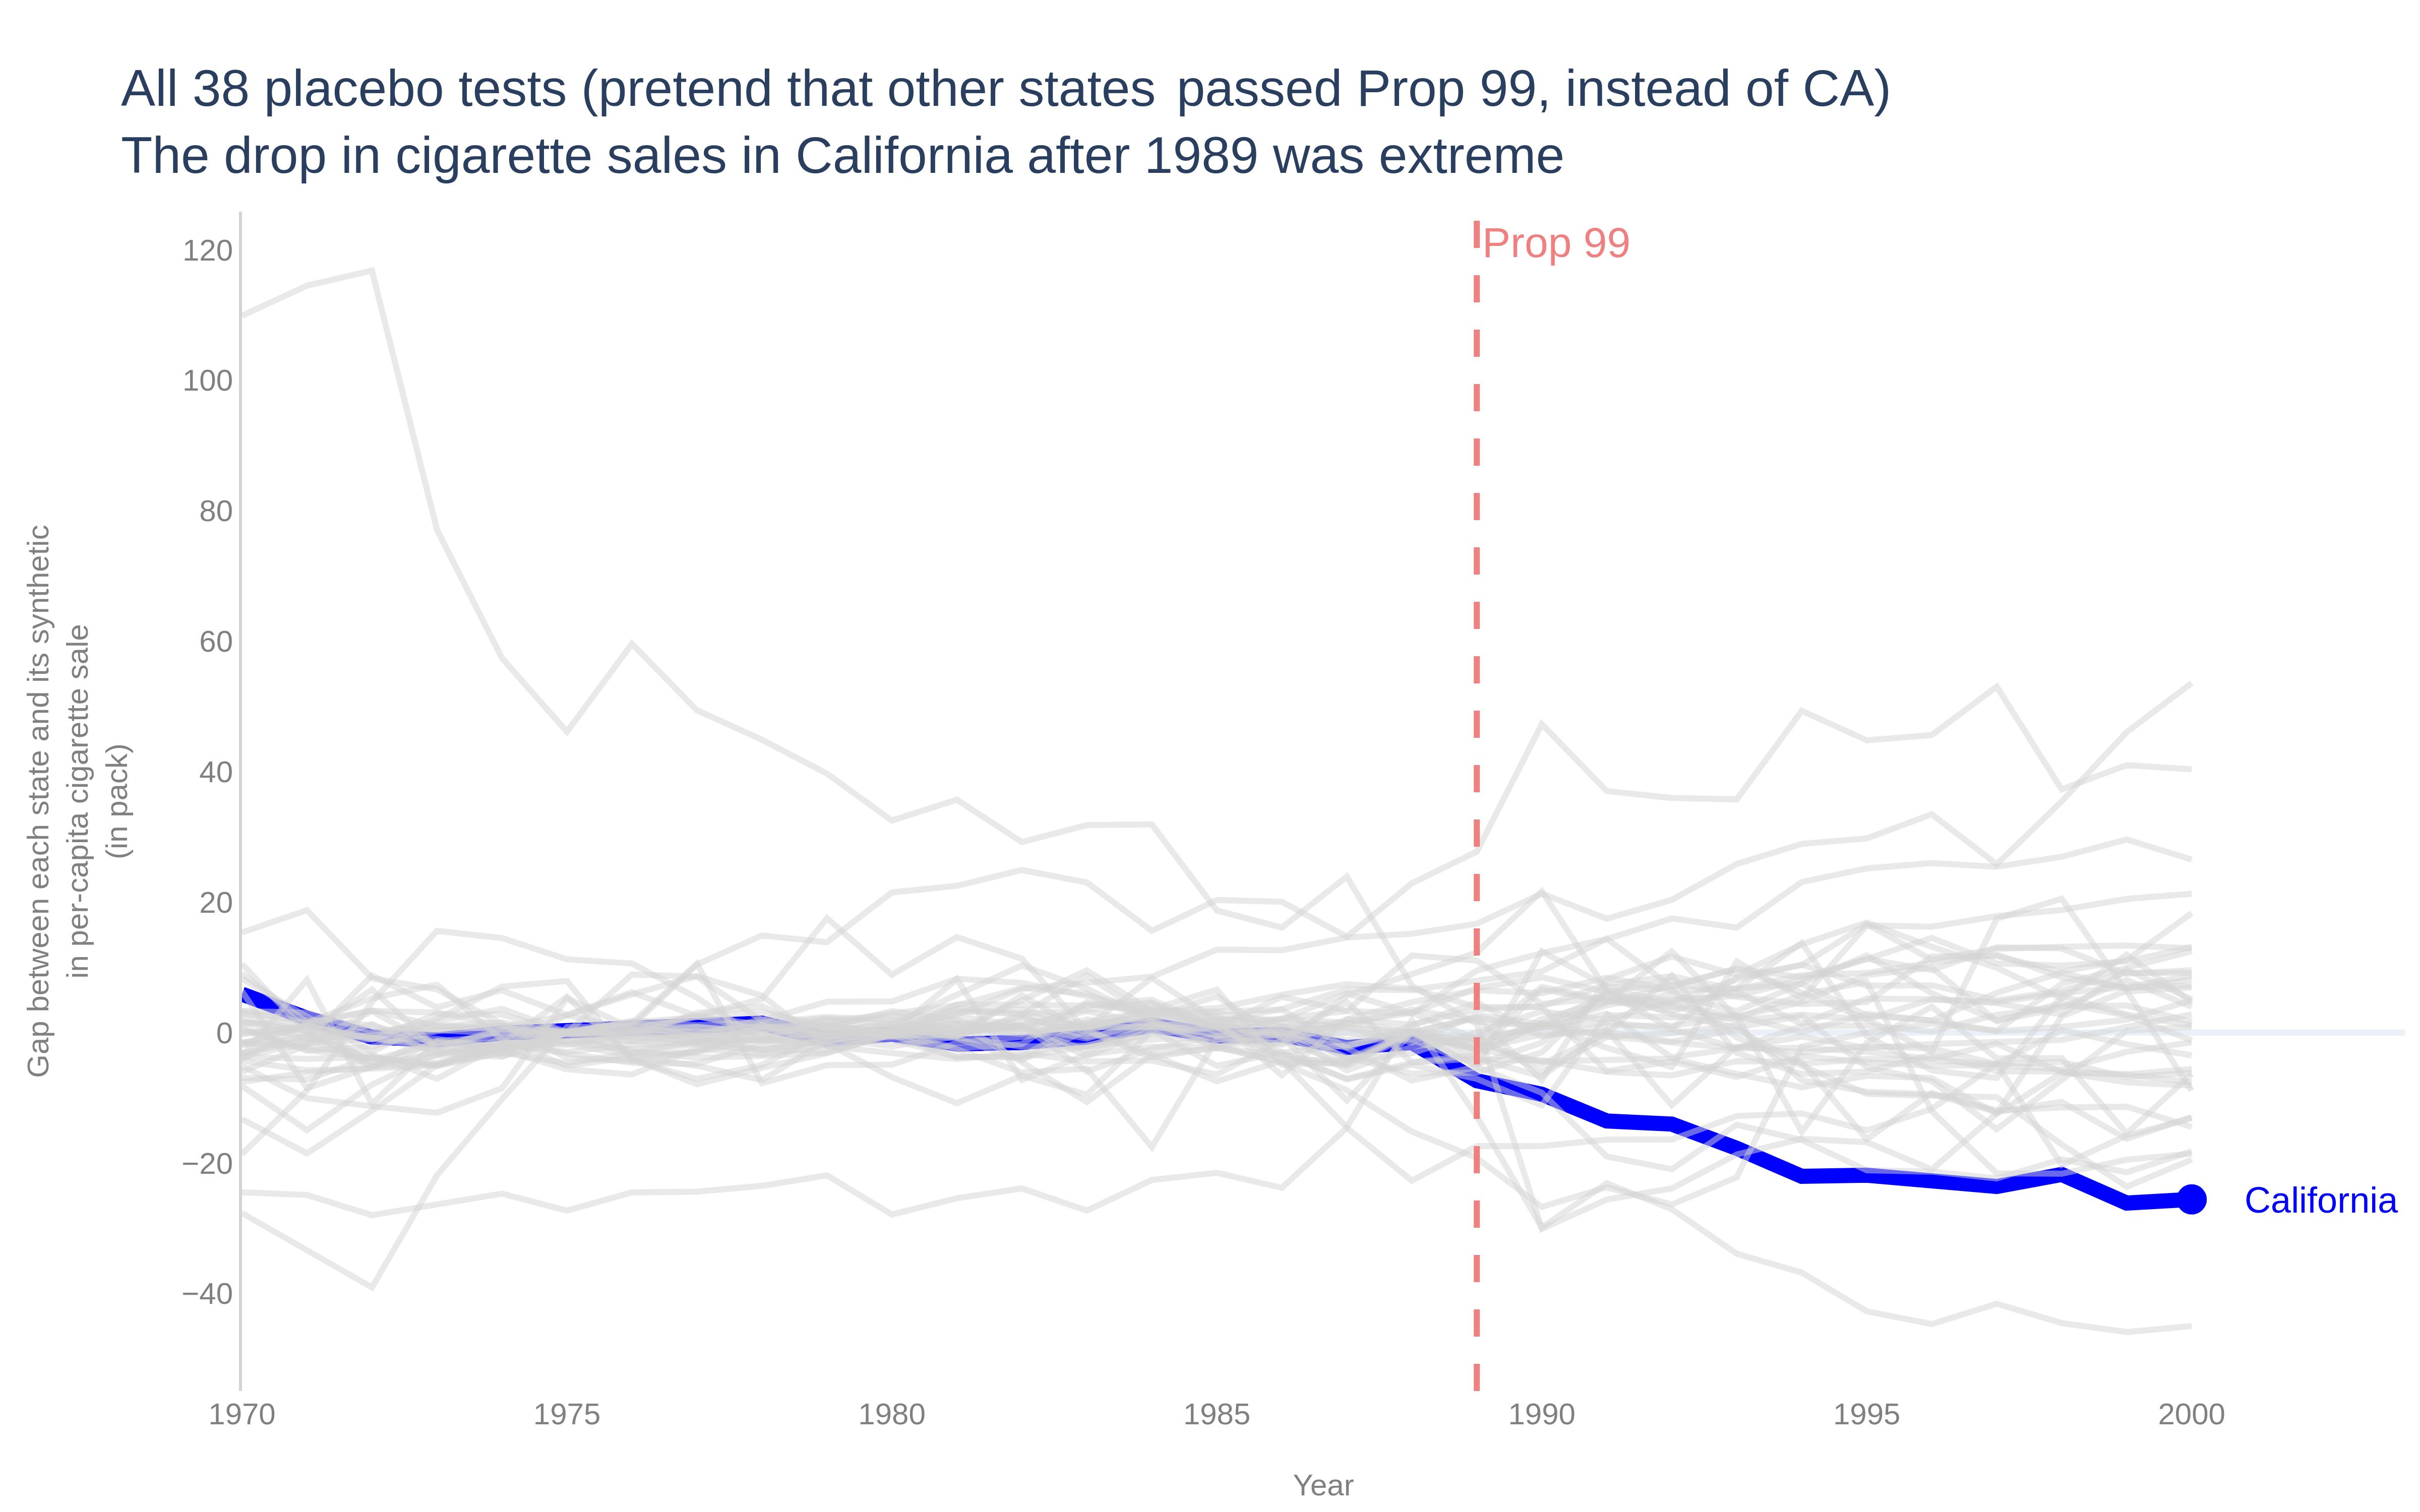

In [ ]:
Image("full_placebo_studies.png")

## Placebo Studies with Filtering out poor pre-treatment fit

In [ ]:
fig = go.Figure()

states = df['state'].unique()
ca_pre_rmse = placebo_results['California']['pre_rmspe']
print(f"CA pre-RMSE benchmark = {ca_pre_rmse}")
for state in states:
    state_pre_rmse = placebo_results[state]['pre_rmspe']
    if state_pre_rmse <= 2*ca_pre_rmse:
      state_data = placebo_results[state]['synth_df']
      if state == 'California':
          fig.add_trace(go.Scatter(x=state_data['year'], y=state_data['Gap'], mode='lines', name=state,
                                  line=dict(color='blue', width=5), showlegend=False))
          fig.add_trace(go.Scatter(x=[2000], y=[state_data[state_data['year'] == 2000]['Gap'].iloc[0]],
                      mode='markers', marker=dict(color='blue', size=10), showlegend=False))
          fig.add_annotation(x=2002, y=state_data[state_data['year'] == 2000]['Gap'].iloc[0],
                            text="California", font=dict(family=font, color='blue'), showarrow=False, arrowhead=1, arrowsize=1, arrowwidth=1, ax=20)

      else:
          fig.add_trace(go.Scatter(x=state_data['year'], y=state_data['Gap'], mode='lines', name=state, opacity=0.5,
                                  line=dict(color='lightgrey'), showlegend=False))
    else:
      print(f"Ignore {state} due to poor fit pre-RMSE = {round(state_pre_rmse, 2)}")

fig.add_vline(x=1989, line=dict(color="lightcoral", width=2, dash="dash")
              ,annotation_text="Prop 99", annotation_position="top right"
              ,annotation_font=dict(color="lightcoral", size=14, family=font))


fig.update_layout(
    title=r"Gap plot after filtering out poor pre-treatment fit, (giving us 19 placebo results)<br>CA clearly stands out",
    xaxis_title='',
    yaxis_title='Gap between each state and its synthetic<br>in per-capita cigarette sale<br>(in pack)',
    # yaxis_tickprefix='$',
    template='plotly_white',
    height=500,width=800,
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False),
    margin=dict(t=70, r=5, b=10),
)

fig.update_xaxes(
    tickfont=dict(color='grey', size=10),
    tickcolor='grey',
    title_text='Year',
    title_font=dict(color='grey', size=10, family=font),
)

fig.update_yaxes(

    title_font=dict(color='grey', size=10, family=font),
    showgrid=False,
    linecolor='lightgrey',
    tickfont=dict(color='grey', size=10),
    tickcolor='grey',
)

# Show plot
fig.show()
fig.write_image("ca_gap_plot_clean.png", scale=6)

CA pre-RMSE benchmark = 1.8023086288284755
Ignore Colorado due to poor fit pre-RMSE = 3.93
Ignore Connecticut due to poor fit pre-RMSE = 4.37
Ignore Delaware due to poor fit pre-RMSE = 9.02
Ignore Indiana due to poor fit pre-RMSE = 3.84
Ignore Iowa due to poor fit pre-RMSE = 3.63
Ignore Kansas due to poor fit pre-RMSE = 4.0
Ignore Kentucky due to poor fit pre-RMSE = 20.95
Ignore Minnesota due to poor fit pre-RMSE = 4.0
Ignore Nevada due to poor fit pre-RMSE = 6.28
Ignore New Hampshire due to poor fit pre-RMSE = 60.63
Ignore North Carolina due to poor fit pre-RMSE = 9.3
Ignore North Dakota due to poor fit pre-RMSE = 4.49
Ignore Oklahoma due to poor fit pre-RMSE = 4.54
Ignore Rhode Island due to poor fit pre-RMSE = 7.26
Ignore Texas due to poor fit pre-RMSE = 3.81
Ignore Utah due to poor fit pre-RMSE = 24.46
Ignore Vermont due to poor fit pre-RMSE = 7.99
Ignore Virginia due to poor fit pre-RMSE = 3.82
Ignore West Virginia due to poor fit pre-RMSE = 4.66
Ignore Wyoming due to poor fit pre

if we only look at states where our model achieved a good pre-intervention fit (meaning the pre-RMSE was not more than twice California's), we are left with 19 states. Among this group, California's effect is the most extreme. The probability of seeing such a significant drop by chance is p-value = 1/19 ≈ 0.052.

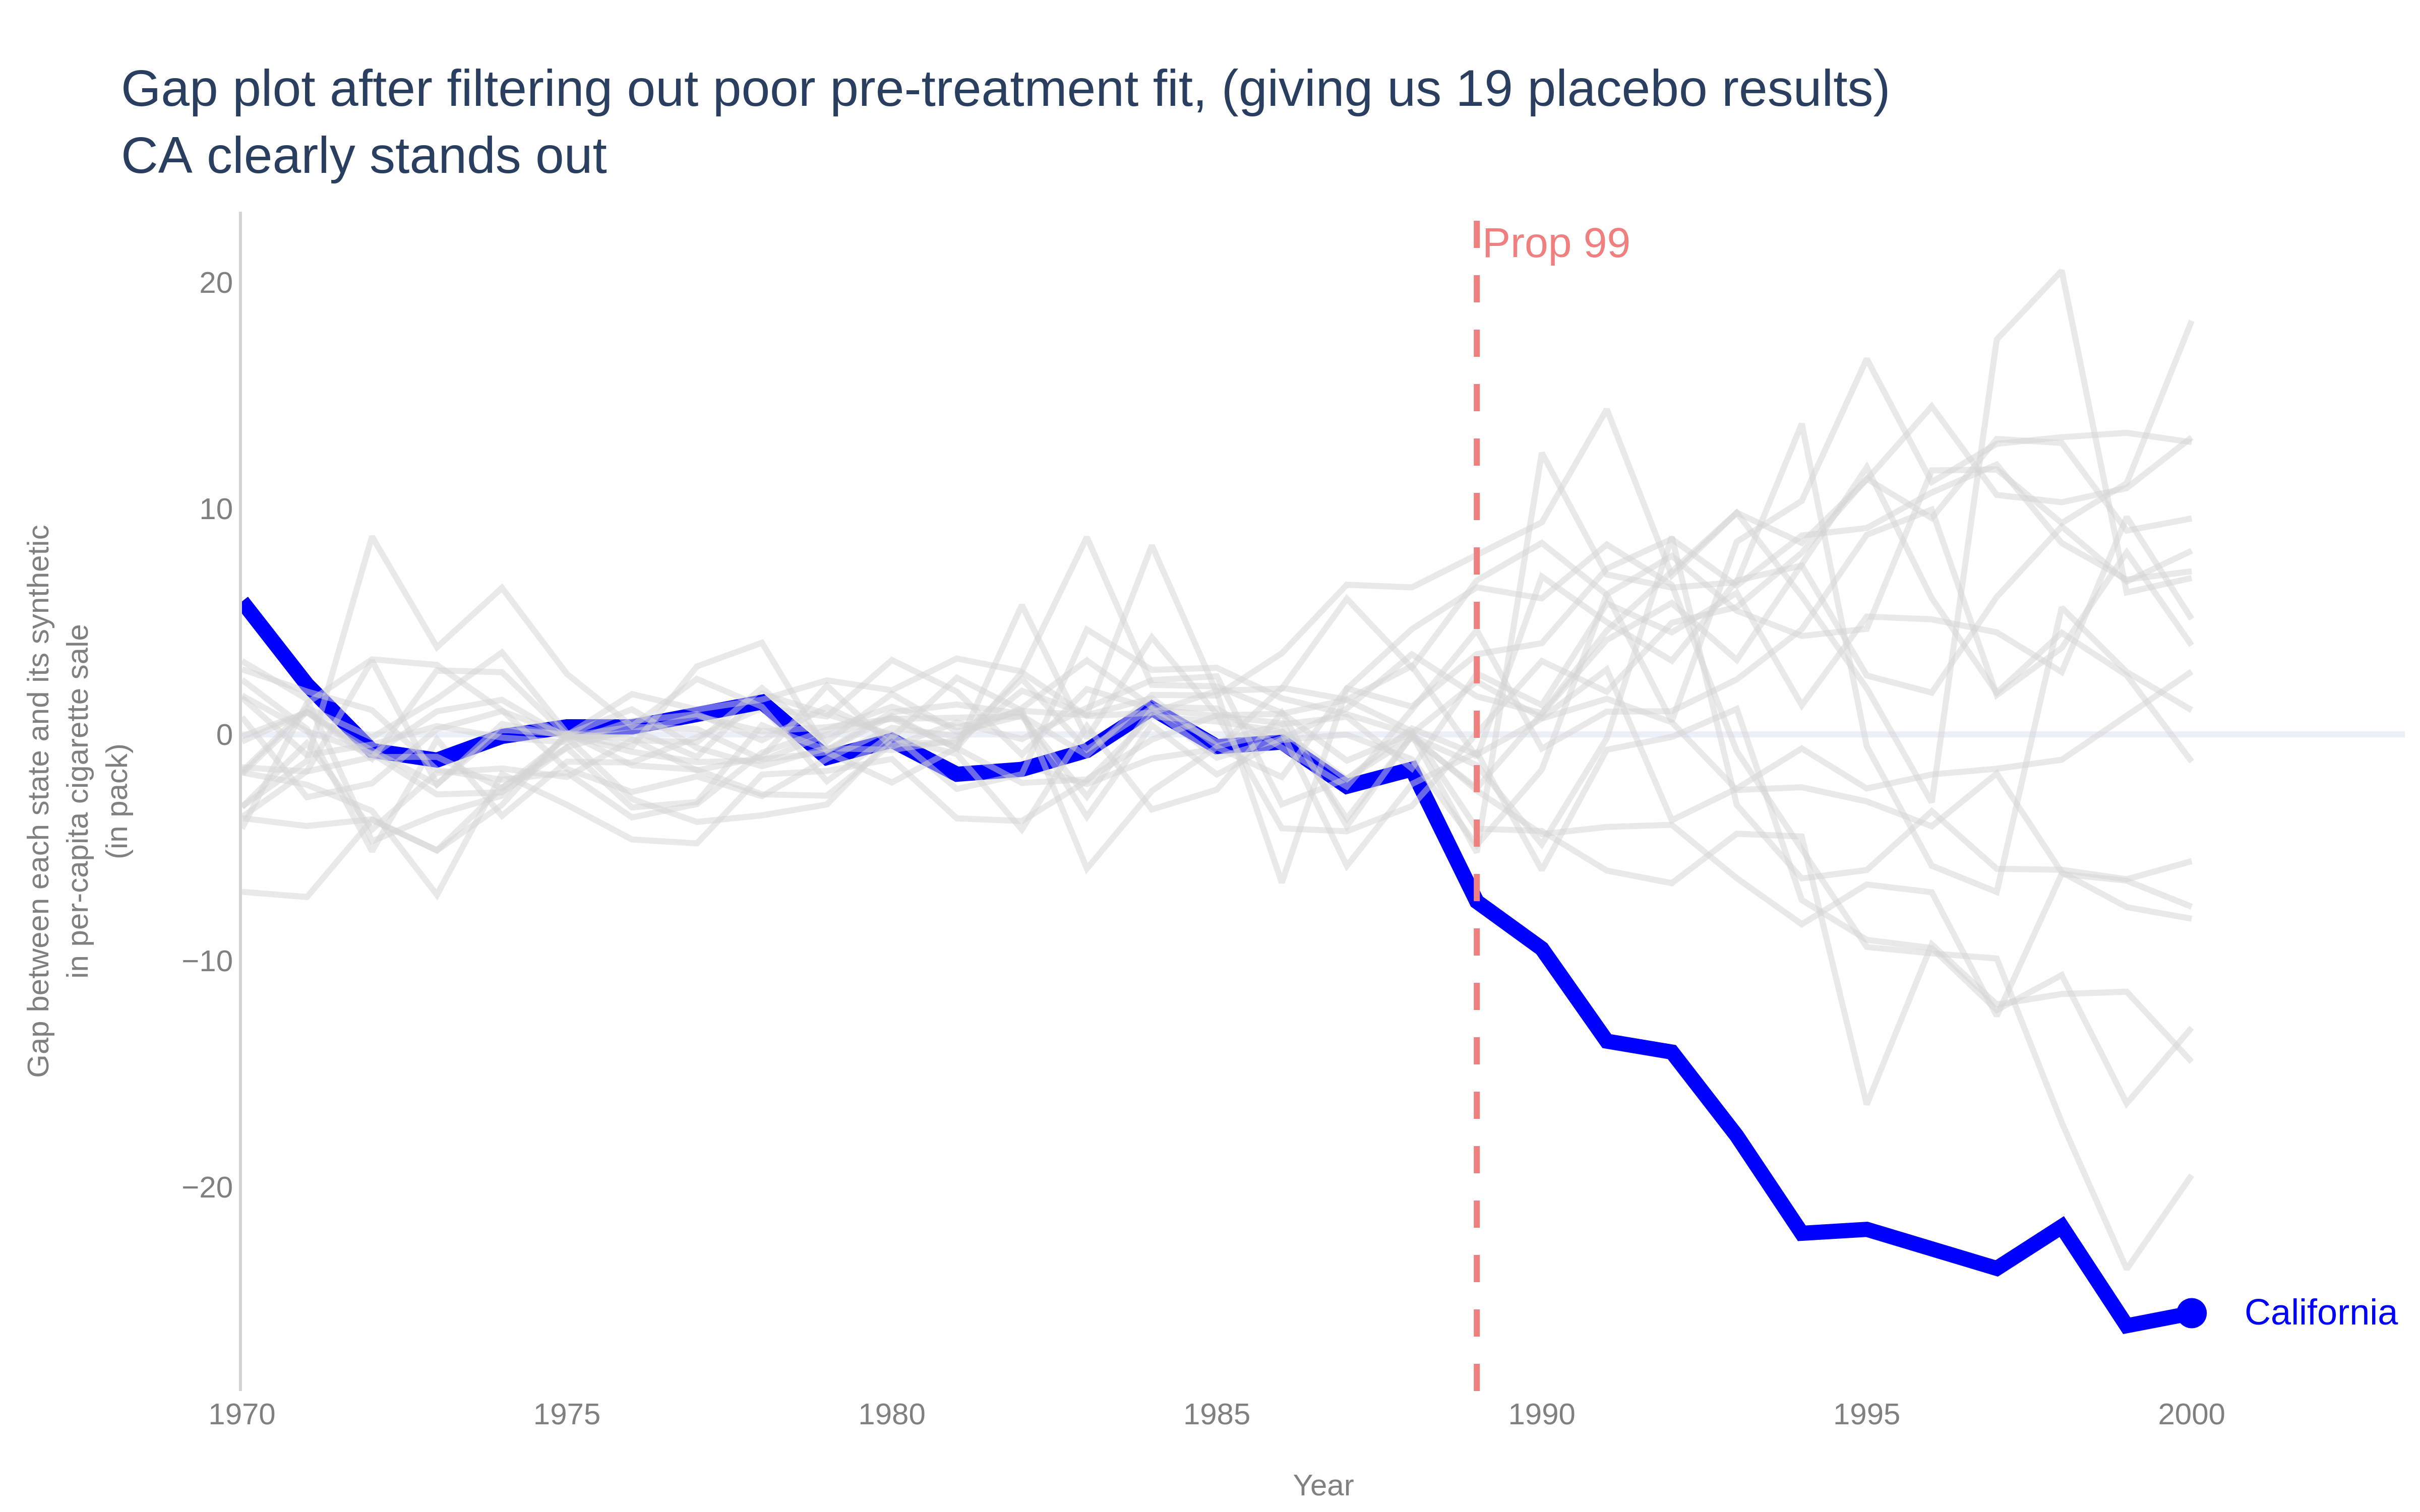

In [ ]:
Image("ca_gap_plot_clean.png")

## Leave One Out Test

In [ ]:
time_col, id_col, outcome_col = 'year', 'state', 'cigsale'
treated_unit, treatment_year = 'California', 1988
df_pivot = df.pivot(index=time_col, columns=id_col, values=outcome_col).sort_index()
display(df_pivot.head(5))
# Covariate Specification which can affect CA cig sales
covariate_spec = {
    'lnincome_avg': ('lnincome', 'mean', (1980, treatment_year)),     # Ln(GDP per capita)
    'age15to24_avg': ('age15to24', 'mean', (1980, treatment_year)),   # Percent aged 15–24
    'retprice_avg': ('retprice', 'mean', (1980, treatment_year)),     # Retail price
    'beer_avg': ('beer', 'mean', (1984, treatment_year)),             # Beer Consumption per capita
    'cigsale_1988': ('cigsale', '', treatment_year),              # Cigarette sales per capita 1988
    'cigsale_1980': ('cigsale', '', 1980),              # Cigarette sales per capita 1980
    'cigsale_1975': ('cigsale', '', 1975),              # Cigarette sales per capita 1975
}

loo_dict = {}
for state in ['Utah', 'Nevada', 'Montana']:
  df_loo = df[df.state != state]
  df_loo_pivot = df_loo.pivot(index=time_col, columns=id_col, values=outcome_col).sort_index()
  cov_df = prepare_covariate(df_loo, covariate_spec, id_col=id_col, time_col=time_col).dropna()
  synth_df, _, _ = synthetic_control_method(df_loo_pivot, cov_df, treated_unit, treatment_year)
  loo_dict[state] = synth_df

state,Alabama,Arkansas,California,Colorado,Connecticut,Delaware,Georgia,Idaho,Illinois,Indiana,...,South Carolina,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,West Virginia,Wisconsin,Wyoming
year,,,,,,,,,,,,,,,,,,,,,
1970.0,89.800003,100.300003,123.000000,124.800003,120.000000,155.000000,109.900002,102.400002,124.800003,134.600006,...,103.599998,92.699997,99.800003,106.400002,65.500000,122.599998,124.300003,114.500000,106.400002,132.199997
1971.0,95.400002,104.099998,121.000000,125.500000,117.599998,161.100006,115.699997,108.500000,125.599998,139.300003,...,115.000000,96.699997,106.300003,108.900002,67.699997,124.400002,128.399994,111.500000,105.400002,131.699997
1972.0,101.099998,103.900002,123.500000,134.300003,110.800003,156.300003,117.000000,126.099998,126.599998,149.199997,...,118.699997,103.000000,111.500000,108.599998,71.300003,138.000000,137.000000,117.500000,108.800003,140.000000
1973.0,102.900002,108.000000,124.400002,137.899994,109.300003,154.699997,119.800003,121.800003,124.400002,156.000000,...,125.500000,103.500000,109.699997,110.400002,72.699997,146.800003,143.100006,116.599998,109.500000,141.199997
1974.0,108.199997,109.699997,126.699997,132.800003,112.400002,151.300003,123.699997,125.599998,131.899994,159.600006,...,129.699997,108.400002,114.800003,114.699997,75.599998,151.800003,149.600006,119.900002,111.800003,145.800003


<ipython-input-6-2349871565>:26: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

<ipython-input-6-2349871565>:26: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

<ipython-input-6-2349871565>:26: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(x=df[df.state=='California']['year'], y=df[df.state=='California']['cigsale'], mode='lines', name='',
                                 line=dict(color='blue'), showlegend=False))

fig.add_trace(go.Scatter(x=synth_df_ca['year'], y=synth_df_ca['Synthetic'], mode='lines', name=f"Synthetic California", opacity=0.5,
                          line=dict(color='rgba(0, 0, 255, 0.85)', dash="dash"), showlegend=False))

fig.add_trace(go.Scatter(x=[2000], y=[df[(df.state=='California')&(df.year == 2000)]['cigsale'].iloc[0]],
            mode='markers', marker=dict(color='blue', size=10), showlegend=False))

fig.add_trace(go.Scatter(x=[2000], y=[synth_df_ca[synth_df_ca['year'] == 2000]['Synthetic'].iloc[0]],
            mode='markers', marker=dict(color='rgba(0, 0, 255, 0.85)', symbol='circle-open-dot',size=10), showlegend=False, opacity=0.5))

alpha = 1
for state, plot_data in loo_dict.items():

    fig.add_trace(go.Scatter(x=plot_data['year'], y=plot_data['Synthetic'], mode='lines', name=f"Leave {state} out",
                            line=dict(color=f'rgba(169, 169, 169, {alpha})'), showlegend=True))
    alpha = alpha - 0.35

fig.add_annotation(x=2001.5, y=40, text="California", font=dict(family=font, color='blue'), showarrow=False, arrowhead=1, arrowsize=1, arrowwidth=1, ax=20)
fig.add_annotation(x=2001.5, y=synth_df_ca[synth_df_ca['year'] == 2000]['Synthetic'].iloc[0], opacity=0.5, text="Synthetic<br>California", font=dict(family=font, color='rgba(0, 0, 255, 0.85)'), showarrow=False, arrowhead=1, arrowsize=1, arrowwidth=1, ax=20)


fig.add_vline(x=treatment_year, line=dict(color="lightcoral", width=2, dash="dash")
              ,annotation_text="Prop 99", annotation_position="top right"
              ,annotation_font=dict(color="lightcoral", size=14, family=font))


fig.update_layout(
    title='When we leave one country out in modeling, we still see a significant difference<br>even in the worst-case scenario when Utah was omitted from the model',
    xaxis_title='',
    yaxis_title='per-capita cigarette sale<br>(in pack)',
    yaxis_tickprefix='$',
    template='plotly_white',
    height=600,width=1000,
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False),
    margin=dict(t=80, r=20, b=15)
)

fig.update_xaxes(
    showgrid=False,
    linecolor='grey',
    tickfont=dict(color='grey', size=10),
    tickcolor='grey',
    title_text='Year',
    title_font=dict(color='grey', size=10, family=font),
)

fig.update_yaxes(
    # title_text='Gap in GDP per Capita',
    title_font=dict(color='grey', size=10, family=font),
    showgrid=False,
    linecolor='grey',
    tickfont=dict(color='grey', size=10),
    tickcolor='grey',
)

# Show plot
fig.show()
fig.write_image("loo_test.png", scale=6)


We removed each donor state with the highest weighted states, such as Utah or Montana, and re-ran the model. The impact remained strong, showing that no one state dominates results.

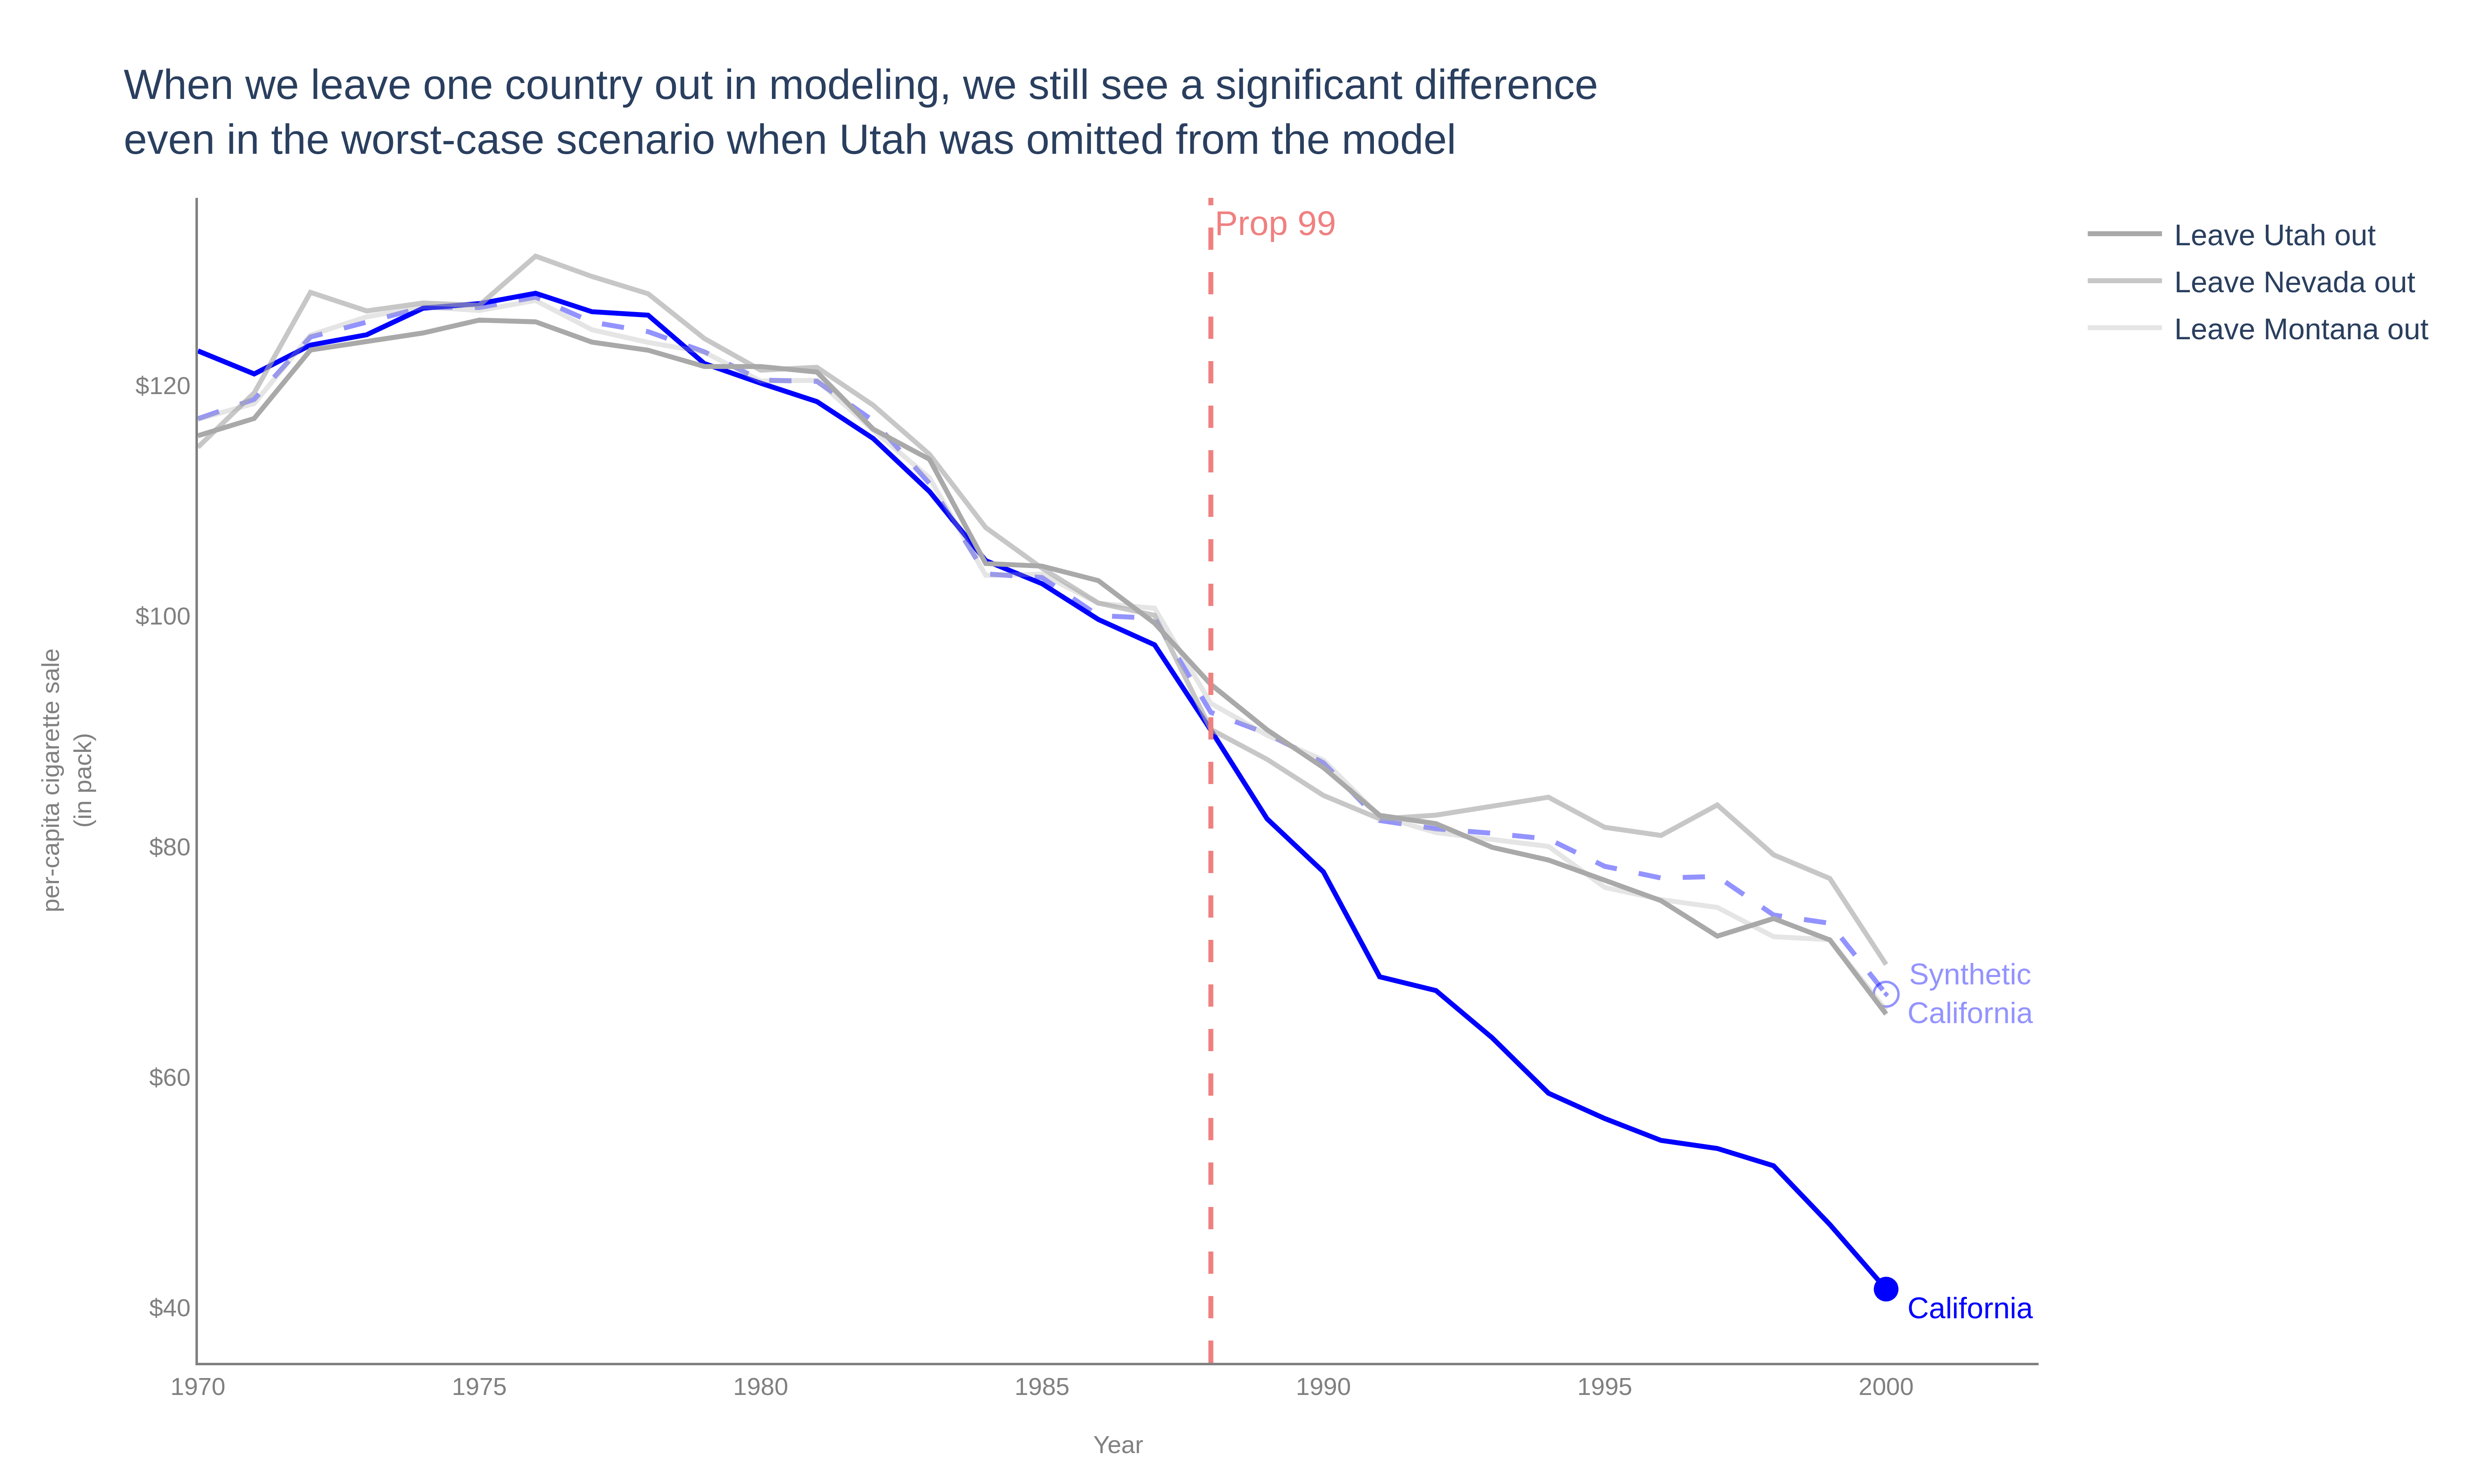

In [ ]:
Image(filename="loo_test.png")